# Objective of This Notebook

The objective of this notebook is to transform the cleaned financial statement dataset into a business-focused KPI dataset suitable for clustering analysis. KPI engineering will be performed using a configurable KPI definition framework, allowing financial metrics to be calculated dynamically from the underlying financial statement data.

Once the KPI dataset has been generated, the notebook will evaluate data quality, prepare the features for modelling, and apply dimensionality reduction and clustering techniques to identify groups of financially similar companies. The resulting clusters will serve as the foundation for automated peer benchmarking and subsequent business interpretation.

# **1. Notebook Setup**

### **1.1 Imports**

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

### **1.2 Notebook Configuration**

In [2]:
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

RANDOM_STATE = 42

# Plot settings
plt.style.use("default")

plt.rcParams["figure.figsize"] = (12, 6)

np.random.seed(RANDOM_STATE)

### **1.3 Paths**

In [3]:
PROJECT_ROOT = Path().resolve().parent

DATA_DIR = PROJECT_ROOT / "data"

RAW_DATA_DIR = DATA_DIR / "raw"
INTERIM_DATA_DIR = DATA_DIR / "interim"
PROCESSED_DATA_DIR = DATA_DIR / "processed"

OUTPUTS_DIR = PROJECT_ROOT / "outputs"

SRC_DIR = PROJECT_ROOT / "src"

# Add project root to Python path
sys.path.append(str(PROJECT_ROOT))

### **1.4 Project Imports**

In [4]:
from src.features.kpi_engine import (
    load_kpi_definitions,
    validate_kpi_definitions,
    calculate_kpis,
)

# **2. Dataset Overview**

### **2.1 Load Clean Dataset**

Here we load the final output from Notebook #2

In [5]:
financials_df = pd.read_excel(
    INTERIM_DATA_DIR / "clean_financials_with_metadata.xlsx"
)

print(f"Dataset shape: {financials_df.shape}")

financials_df.head()

Dataset shape: (4576, 222)


,Symbol,Company Name,Exchange,Sector,Industry,Employees,MarketCap,EnterpriseValue,Tax Effect Of Unusual Items,Tax Rate For Calcs,Normalized EBITDA,Total Unusual Items,Total Unusual Items Excluding Goodwill,Net Income From Continuing Operation Net Minority Interest,Reconciled Depreciation,Reconciled Cost Of Revenue,EBITDA,EBIT,Net Interest Income,Interest Expense,Interest Income,Normalized Income,Net Income From Continuing And Discontinued Operation,Total Expenses,Total Operating Income As Reported,Diluted Average Shares,Basic Average Shares,Diluted EPS,Basic EPS,Diluted NI Availto Com Stockholders,Net Income Common Stockholders,Net Income,Net Income Including Noncontrolling Interests,Net Income Continuous Operations,Tax Provision,Pretax Income,Other Income Expense,Other Non Operating Income Expenses,Special Income Charges,Other Special Charges,Impairment Of Capital Assets,Gain On Sale Of Security,Net Non Operating Interest Income Expense,Interest Expense Non Operating,Interest Income Non Operating,Operating Income,Operating Expense,Depreciation Amortization Depletion Income Statement,Depreciation And Amortization In Income Statement,Research And Development,Selling General And Administration,Selling And Marketing Expense,General And Administrative Expense,Other Gand A,Gross Profit,Cost Of Revenue,Total Revenue,Operating Revenue,Treasury Shares Number,Ordinary Shares Number,Share Issued,Net Debt,Total Debt,Tangible Book Value,Invested Capital,Working Capital,Net Tangible Assets,Capital Lease Obligations,Common Stock Equity,Total Capitalization,Total Equity Gross Minority Interest,Stockholders Equity,Gains Losses Not Affecting Retained Earnings,Other Equity Adjustments,Retained Earnings,Additional Paid In Capital,Capital Stock,Common Stock,Preferred Stock,Total Liabilities Net Minority Interest,Total Non Current Liabilities Net Minority Interest,Other Non Current Liabilities,Non Current Deferred Liabilities,Non Current Deferred Taxes Liabilities,Long Term Debt And Capital Lease Obligation,Long Term Capital Lease Obligation,Long Term Debt,Current Liabilities,Other Current Liabilities,Current Deferred Liabilities,Current Deferred Revenue,Current Debt And Capital Lease Obligation,Current Debt,Other Current Borrowings,Payables And Accrued Expenses,Current Accrued Expenses,Payables,Total Tax Payable,Income Tax Payable,Accounts Payable,Total Assets,Total Non Current Assets,Other Non Current Assets,Non Current Deferred Assets,Non Current Deferred Taxes Assets,Goodwill And Other Intangible Assets,Other Intangible Assets,Goodwill,Net PPE,Accumulated Depreciation,Gross PPE,Leases,Other Properties,Machinery Furniture Equipment,Properties,Current Assets,Other Current Assets,Receivables,Taxes Receivable,Accounts Receivable,Allowance For Doubtful Accounts Receivable,Gross Accounts Receivable,Cash Cash Equivalents And Short Term Investments,Cash And Cash Equivalents,Free Cash Flow,Repurchase Of Capital Stock,Repayment Of Debt,Issuance Of Debt,Capital Expenditure,Interest Paid Supplemental Data,Income Tax Paid Supplemental Data,End Cash Position,Beginning Cash Position,Effect Of Exchange Rate Changes,Changes In Cash,Financing Cash Flow,Cash Flow From Continuing Financing Activities,Net Other Financing Charges,Proceeds From Stock Option Exercised,Net Common Stock Issuance,Common Stock Payments,Net Issuance Payments Of Debt,Net Short Term Debt Issuance,Net Long Term Debt Issuance,Long Term Debt Payments,Long Term Debt Issuance,Investing Cash Flow,Cash Flow From Continuing Investing Activities,Net Business Purchase And Sale,Sale Of Business,Purchase Of Business,Net PPE Purchase And Sale,Purchase Of PPE,Capital Expenditure Reported,Operating Cash Flow,Cash Flow From Continuing Operating Activities,Change In Working Capital,Change In Other Working Capital,Change In Other Current Assets,Change In Payables And Accrued Expense,Change In Accrued Expense,Change In Payable,Change In Account Payable,Change In Tax Payable,Change In Income Tax Payable,Change

### **2.2 Dataset description**

In [6]:
# ==================================================
# Initial Dataset Validation
# ==================================================

print(f"Number of companies: {financials_df['Symbol'].nunique():,}")

print(f"Number of sectors: {financials_df['Sector'].nunique():,}")

print(f"Number of industries: {financials_df['Industry'].nunique():,}")

Number of companies: 4,576
Number of sectors: 11
Number of industries: 145


In [7]:
financials_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4576 entries, 0 to 4575
Columns: 222 entries, Symbol to Long Term Equity Investment
dtypes: float64(217), str(5)
memory usage: 8.1 MB


In [8]:
financials_df.describe().T.head(20)

,count,mean,std,min,25%,50%,75%,max
Employees,4195.0,1.231073e+04,5.583885e+04,1.000000e+00,1.610000e+02,1.139000e+03,6.500000e+03,2.100000e+06
MarketCap,4570.0,2.108848e+10,1.729725e+11,1.308890e+05,1.516642e+08,1.159357e+09,6.347573e+09,5.189349e+12
EnterpriseValue,4512.0,7.891645e+10,2.608636e+12,-5.515685e+13,1.737587e+08,1.512113e+09,8.821250e+09,1.264616e+14
Tax Effect Of Unusual Items,4573.0,-3.105859e+08,1.463905e+10,-7.838690e+11,-1.765680e+06,0.000000e+00,0.000000e+00,2.348990e+11
Tax Rate For Calcs,4569.0,1.716604e-01,1.038284e-01,0.000000e+00,9.300000e-02,2.100000e-01,2.330000e-01,4.000000e-01
Normalized EBITDA,4048.0,3.270788e+10,1.788561e+12,-6.651988e+13,-5.521470e+06,6.408400e+07,6.144380e+08,7.343200e+13
Total Unusual Items,3626.0,-2.167490e+09,8.837795e+10,-3.919345e+12,-2.876875e+07,-1.314000e+06,1.049750e+06,8.945870e+11
Total Unusual Items Excluding Goodwill,3627.0,-2.167066e+09,8.836577e+10,-3.919345e+12,-2.878950e+07,-1.316000e+06,1.049500e+06,8.945870e+11
Net Income From Continuing Operation Net Minority Interest,4572.0,-5.395741e+09,1.513552e+12,-9.938466e+13,-2.243575e+07,1.190650e+07,2.339192e+08,1.748600e+13
Reconciled Depreciation,4472.0,2.465760e+10,6.815284e+11,-1.829000e+09,3.149193e+06,2.731600e+07,1.759378e+08,3.765300e+13


# **3. KPI Engineering**

### **3.1 Load KPI Definitions**

In [9]:
kpi_definitions_path = PROJECT_ROOT / "config" / "kpi_definitions.csv"

kpi_definitions = load_kpi_definitions(kpi_definitions_path)

print(f"Number of KPI definitions: {len(kpi_definitions)}")

kpi_definitions

Number of KPI definitions: 20


,ID,KPI,Category,UoM,What is better?,Formula,Required Fields,Include in Clustering
0,1,Gross Margin,Profitability,%,Bigger better,(`Total Revenue` - `Cost Of Revenue`) / `Total...,Total Revenue; Cost Of Revenue,Yes
1,2,Operating Margin,Profitability,%,Bigger better,`Operating Income` / `Total Revenue`,Operating Income; Total Revenue,Yes
2,3,Net Margin,Profitability,%,Bigger better,`Net Income` / `Total Revenue`,Net Income; Total Revenue,Yes
3,4,EBITDA Margin,Profitability,%,Bigger better,`EBITDA` / `Total Revenue`,EBITDA; Total Revenue,Yes
4,5,Return on Assets,Profitability,%,Bigger better,`Net Income` / `Total Assets`,Net Income; Total Assets,Yes
5,6,Return on Equity,Profitability,%,Bigger better,`Net Income` / `Stockholders Equity`,Net Income; Stockholders Equity,Yes
6,7,Asset Turnover,Efficiency,Ratio,Bigger better,`Total Revenue` / `Total Assets`,Total Revenue; Total Assets,Yes
7,8,Revenue per Employee,Productivity,USD,Bigger better,`Total Revenue` / `Employees`,Total Revenue; Employees,Yes
8,9,Current Ratio,Liquidity,Ratio,Bigger better,`Current Assets` / `Current Liabilities`,Current Assets; Current Liabilities,Yes
9,10,Quick Ratio,Liquidity,Ratio,Bigger better,(`Current Assets` - `Inventory`) / `Current Li...,Current Assets; Inventory; Current Liabilities,Yes


### **3.2 Validate KPI Definitions**

In [10]:
kpi_validation = validate_kpi_definitions(
    data=financials_df,
    kpi_definitions=kpi_definitions
)

kpi_validation

,KPI,Required Fields,Missing Fields,Can Calculate
0,Gross Margin,"[Total Revenue, Cost Of Revenue]",[],True
1,Operating Margin,"[Operating Income, Total Revenue]",[],True
2,Net Margin,"[Net Income, Total Revenue]",[],True
3,EBITDA Margin,"[EBITDA, Total Revenue]",[],True
4,Return on Assets,"[Net Income, Total Assets]",[],True
5,Return on Equity,"[Net Income, Stockholders Equity]",[],True
6,Asset Turnover,"[Total Revenue, Total Assets]",[],True
7,Revenue per Employee,"[Total Revenue, Employees]",[],True
8,Current Ratio,"[Current Assets, Current Liabilities]",[],True
9,Quick Ratio,"[Current Assets, Inventory, Current Liabilities]",[],True


### **3.3 Calculate KPI**

In [11]:
kpi_df = calculate_kpis(
    data=financials_df,
    kpi_definitions=kpi_definitions
)

print(f"KPI dataset shape: {kpi_df.shape}")

kpi_df.head()

KPI dataset shape: (4576, 25)


,Symbol,Company Name,Exchange,Sector,Industry,Gross Margin,Operating Margin,Net Margin,EBITDA Margin,Return on Assets,Return on Equity,Asset Turnover,Revenue per Employee,Current Ratio,Quick Ratio,Cash Ratio,Debt to Equity,Debt Ratio,Equity Ratio,Operating Cash Flow Margin,Free Cash Flow Margin,Cash Conversion Ratio,Market Cap to Revenue,Enterprise Value to Revenue,Enterprise Value to EBITDA
0,ACCS,ACCESS Newswire Inc. Common Stock,AMEX,Communication Services,Advertising Agencies,0.765463,-0.071665,0.189708,0.046067,0.102186,0.141407,0.538650,2.485604e+05,0.882994,NaN,0.317152,0.094678,0.068418,0.722638,0.024670,0.016181,0.130040,1.084714,1.076394,23.365605
1,AGIG,Abundia Global Impact Group Inc. Common stock,AMEX,Utilities,Utilities - Renewable,-0.047454,-25.858421,-71.724291,-69.686045,-0.924561,-1.548945,0.012890,2.053160e+05,0.836948,NaN,0.721485,0.546426,0.326160,0.596897,-19.608939,-44.075759,0.273393,125.432738,97.566142,-1.400081
2,AIB,"BlockchAIn Digital Infrastructure, Inc Common ...",AMEX,Technology,Software - Application,0.189844,-0.048485,-0.045118,-0.001916,-0.048382,-0.106299,1.072338,6.172204e+06,0.397528,NaN,0.001749,0.010397,0.004732,0.455148,0.126155,0.124052,-2.796112,7.339492,6.117684,-3192.660184
3,AIRI,Air Industries Group Common Stock,AMEX,Industrials,Aerospace & Defense,0.170844,-0.007053,-0.027232,0.078817,-0.022373,-0.067965,0.821564,2.995062e+05,1.243726,0.332917,0.018077,1.604396,0.528142,0.329184,-0.028213,-0.097536,1.036015,0.307715,0.969575,12.301565
4,AMBO,Ambow Education Holding Ltd. American Deposito...,AMEX,Consumer Defensive,Education & Training Services,0.547576,0.011828,0.143521,0.103179,0.065349,0.164727,0.455328,2.309512e+05,2.201539,2.185335,0.168321,1.178788,0.467638,0.396711,0.014468,-0.089767,0.100809,0.746118,15.444388,149.685683


Joining back the Total Revenue and MarketCap as we need it after

In [12]:
print("Rows in financials_df:", len(financials_df))
print("Rows in kpi_df (before merge):", len(kpi_df))

# --- Merge Total Revenue into KPI dataframe ---
kpi_df = kpi_df.merge(
    financials_df[['Symbol', 'Total Revenue', 'MarketCap']],
    on='Symbol',
    how='left'
)

print("Rows in kpi_df (after merge):", len(kpi_df))


Rows in financials_df: 4576
Rows in kpi_df (before merge): 4576
Rows in kpi_df (after merge): 4576


# **4. Quality Control**

### **4.1 Business Eligibility Filtering**

In [13]:
MIN_REVENUE = 25_000_000 # 10M is reasonable but allows unstable margins that bias the data, 50M is too restrictive

eligible_kpi_df = kpi_df[
    kpi_df["Total Revenue"] >= MIN_REVENUE
].copy()

print(f"Companies before revenue eligibility filter: {len(kpi_df):,}")
print(f"Companies after revenue eligibility filter: {len(eligible_kpi_df):,}")

Companies before revenue eligibility filter: 4,576
Companies after revenue eligibility filter: 3,809


In [14]:
# Revenue Distribution Diagnostics

kpi_df["Total Revenue"].describe(percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75])

count    4.576000e+03
mean     1.800574e+11
std      3.734056e+12
min      5.500000e+02
1%       8.252400e+04
5%       2.000000e+06
10%      7.843546e+06
25%      6.852400e+07
50%      5.943835e+08
75%      3.379406e+09
max      1.467420e+14
Name: Total Revenue, dtype: float64

In [15]:
# Companies with extremely low revenue
low_revenue_companies = kpi_df[
    kpi_df["Total Revenue"] < MIN_REVENUE
].sort_values("Total Revenue")

low_revenue_companies[
    [
        "Symbol",
        "Company Name",
        "Sector",
        "Industry",
        "Total Revenue",
        "EBITDA Margin",
        "Free Cash Flow Margin",
        "MarketCap"
    ]
].head(30)

,Symbol,Company Name,Sector,Industry,Total Revenue,EBITDA Margin,Free Cash Flow Margin,MarketCap
1779,MYSE,"Myseum.AI, Inc. - Common Stock",Technology,Software - Application,550.0,-9845.523636,-8123.430909,9083049.0
226,ADTX,"Aditxt, Inc. - Common Stock",Healthcare,Biotechnology,3195.0,-12559.181847,-8044.476369,133811.0
589,CABR,"Caring Brands, Inc. - Common Stock",Healthcare,Drug Manufacturers - Specialty & Generic,4215.0,-731.915777,-401.484698,10546147.0
1284,HSCS,HeartSciences Inc. - Common Stock,Healthcare,Medical Devices,4350.0,-1870.533333,-1711.076322,5716536.0
2507,TCRT,"Alaunos Therapeutics, Inc. - Common Stock",Healthcare,Biotechnology,5000.0,-843.600000,-593.400000,7472966.0
650,CELZ,"Creative Medical Technology Holdings, Inc. - C...",Healthcare,Biotechnology,6000.0,-1003.247833,-976.074167,8335987.0
379,ASBP,"Aspire Biopharma Holdings, Inc. - Common Stock",Healthcare,Biotechnology,6202.0,-2571.682199,-793.854886,7162644.0
2690,VRAX,Virax Biolabs Group Limited - Ordinary Shares,Healthcare,Biotechnology,6331.0,-916.494551,-816.216396,1570798.0
317,AMOD,"Alpha Modus Holdings, Inc. - Class A Common Stock",Technology,Software - Application,7138.0,-565.927991,-450.859064,12459010.0
1177,GNLX,Genelux Corporation - Common Stock,Healthcare,Biotechnology,8000.0,-4080.000000,-3295.750000,137660080.0


In [16]:
for threshold in [1_000_000, 5_000_000, 10_000_000, 25_000_000, 50_000_000, 100_000_000]:
    count = (kpi_df["Total Revenue"] >= threshold).sum()
    print(f"Revenue >= ${threshold:,.0f}: {count:,} companies")

Revenue >= $1,000,000: 4,412 companies
Revenue >= $5,000,000: 4,209 companies
Revenue >= $10,000,000: 4,071 companies
Revenue >= $25,000,000: 3,809 companies
Revenue >= $50,000,000: 3,556 companies
Revenue >= $100,000,000: 3,234 companies


So the dataset contains a long tail of very low-revenue public companies. Many of them are biotech, pre-commercial healthcare, early-stage tech, or distressed/special-case companies. Their financial ratios explode because the denominator is tiny.

### **4.2 Revenue Eligibility by Sector**

In [17]:
# ==================================================
# Revenue Eligibility by Sector
# ==================================================

revenue_eligibility_by_sector = (
    kpi_df
    .assign(IsEligible=lambda df: df["Total Revenue"] >= MIN_REVENUE)
    .groupby("Sector")["IsEligible"]
    .agg(["count", "sum", "mean"])
    .rename(columns={
        "count": "Total Companies",
        "sum": "Eligible Companies",
        "mean": "Eligibility Rate"
    })
    .sort_values("Eligible Companies", ascending=False)
)

revenue_eligibility_by_sector

,Total Companies,Eligible Companies,Eligibility Rate
Sector,,,
Financial Services,707,641,0.906648
Technology,751,590,0.785619
Industrials,660,554,0.839394
Healthcare,740,500,0.675676
Consumer Cyclical,527,460,0.872865
Communication Services,253,228,0.901186
Basic Materials,219,195,0.890411
Consumer Defensive,230,195,0.847826
Energy,206,193,0.936893


### **4.3 Identify KPI Columns**

In [18]:
metadata_columns = [
    "Symbol",
    "Company Name",
    "Exchange",
    "Sector",
    "Industry",
]

kpi_columns = [
    col for col in eligible_kpi_df.columns
    if col not in metadata_columns
]

print(f"Number of KPI columns: {len(kpi_columns)}")
kpi_columns

Number of KPI columns: 22


['Gross Margin',
 'Operating Margin',
 'Net Margin',
 'EBITDA Margin',
 'Return on Assets',
 'Return on Equity',
 'Asset Turnover',
 'Revenue per Employee',
 'Current Ratio',
 'Quick Ratio',
 'Cash Ratio',
 'Debt to Equity',
 'Debt Ratio',
 'Equity Ratio',
 'Operating Cash Flow Margin',
 'Free Cash Flow Margin',
 'Cash Conversion Ratio',
 'Market Cap to Revenue',
 'Enterprise Value to Revenue',
 'Enterprise Value to EBITDA',
 'Total Revenue',
 'MarketCap']

### **4.4 KPI Missing Value Analysis**

In [19]:
kpi_missing_summary = (
    eligible_kpi_df[kpi_columns]
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .reset_index()
)

kpi_missing_summary.columns = ["KPI", "Missing %"]

kpi_missing_summary

,KPI,Missing %
0,Quick Ratio,39.459176
1,Gross Margin,15.200840
2,Enterprise Value to EBITDA,14.281964
3,Cash Ratio,13.494355
4,Current Ratio,13.389341
5,Operating Margin,13.284327
6,EBITDA Margin,13.284327
7,Revenue per Employee,7.088475
8,Debt to Equity,2.704122
9,Debt Ratio,2.179050


### **4.5 KPI Distribution Summary**

In [20]:
eligible_kpi_df[kpi_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Gross Margin,3230.0,4.179450e-01,2.807836e-01,-4.361503e+00,2.324958e-01,3.956873e-01,6.012306e-01,2.920271e+00
Operating Margin,3303.0,-5.065975e-02,8.765533e-01,-2.190575e+01,-2.208881e-02,6.867452e-02,1.688157e-01,1.615151e+01
Net Margin,3804.0,-7.937732e-02,1.014595e+00,-2.618382e+01,-4.920801e-02,4.878194e-02,1.545252e-01,1.729894e+01
EBITDA Margin,3303.0,-4.350278e-03,1.058724e+00,-2.614368e+01,9.587561e-03,1.176178e-01,2.552080e-01,2.296902e+00
Return on Assets,3801.0,5.362225e-01,3.515799e+01,-3.223611e+01,-3.112453e-02,1.774402e-02,6.109242e-02,2.167230e+03
Return on Equity,3781.0,-2.468437e+01,1.510355e+03,-9.287120e+04,-6.459521e-02,7.881329e-02,1.611648e-01,3.948148e+01
Asset Turnover,3806.0,1.263804e+00,2.944726e+01,3.009175e-03,2.646191e-01,5.597577e-01,9.598995e-01,1.813641e+03
Revenue per Employee,3539.0,6.538427e+06,1.449260e+08,8.746689e+03,3.103624e+05,4.930215e+05,1.014190e+06,7.690074e+09
Current Ratio,3299.0,2.793567e+00,1.157307e+01,2.876521e-02,1.078062e+00,1.685302e+00,2.814601e+00,6.386798e+02
Quick Ratio,2306.0,1.966297e+00,2.558429e+00,4.106309e-02,7.849278e-01,1.265786e+00,2.137438e+00,3.886399e+01


# **5. Peer and KPI Universe Filtering**

### **5.1 Filter KPIs for Clustering**

In [21]:
# Here we filter KPIs Included in Clustering

clustering_kpis = (
    kpi_definitions[
        kpi_definitions["Include in Clustering"].str.lower() == "yes"
    ]["KPI"]
    .tolist()
)

available_clustering_kpis = [
    kpi for kpi in clustering_kpis
    if kpi in eligible_kpi_df.columns
]

print(f"KPIs selected for clustering: {len(available_clustering_kpis)}")
available_clustering_kpis

KPIs selected for clustering: 17


['Gross Margin',
 'Operating Margin',
 'Net Margin',
 'EBITDA Margin',
 'Return on Assets',
 'Return on Equity',
 'Asset Turnover',
 'Revenue per Employee',
 'Current Ratio',
 'Quick Ratio',
 'Cash Ratio',
 'Debt to Equity',
 'Debt Ratio',
 'Equity Ratio',
 'Operating Cash Flow Margin',
 'Free Cash Flow Margin',
 'Cash Conversion Ratio']

In [22]:
# Remove Companies Missing Required Clustering KPIs

MIN_KPI_COVERAGE = 0.70
MIN_COMPANY_KPI_COMPLETENESS = 0.70

kpi_coverage = eligible_kpi_df[available_clustering_kpis].notna().mean()

selected_clustering_kpis = kpi_coverage[
    kpi_coverage >= MIN_KPI_COVERAGE
].index.tolist()

print(f"Original clustering KPIs: {len(available_clustering_kpis)}")
print(f"Selected clustering KPIs after coverage filter: {len(selected_clustering_kpis)}")

kpi_coverage.sort_values()

Original clustering KPIs: 17
Selected clustering KPIs after coverage filter: 16


Quick Ratio                   0.605408
Gross Margin                  0.847992
Cash Ratio                    0.865056
Current Ratio                 0.866107
EBITDA Margin                 0.867157
Operating Margin              0.867157
Revenue per Employee          0.929115
Debt to Equity                0.972959
Debt Ratio                    0.978210
Cash Conversion Ratio         0.992386
Return on Equity              0.992649
Operating Cash Flow Margin    0.993699
Equity Ratio                  0.996850
Free Cash Flow Margin         0.997375
Return on Assets              0.997900
Net Margin                    0.998687
Asset Turnover                0.999212
dtype: float64

In [23]:
# Filter Companies by KPI Completeness

company_kpi_completeness = eligible_kpi_df[selected_clustering_kpis].notna().mean(axis=1)

modeling_df = eligible_kpi_df[
    company_kpi_completeness >= MIN_COMPANY_KPI_COMPLETENESS
].copy()

print(f"Companies before KPI filtering: {len(eligible_kpi_df):,}")
print(f"Companies after KPI completeness filtering: {len(modeling_df):,}")

Companies before KPI filtering: 3,809


Companies after KPI completeness filtering: 3,304


### **5.2 Revenue Distribution Diagnostics**

In [24]:
kpi_df["Total Revenue"].describe(percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75]) # we want to see the before vs after

# Companies with extremely low revenue
low_revenue_companies = kpi_df[
    kpi_df["Total Revenue"] < MIN_REVENUE
].sort_values("Total Revenue")

low_revenue_companies[
    [
        "Symbol",
        "Company Name",
        "Sector",
        "Industry",
        "Total Revenue",
        "EBITDA Margin",
        "Free Cash Flow Margin",
        "MarketCap"
    ]
].head(30)

,Symbol,Company Name,Sector,Industry,Total Revenue,EBITDA Margin,Free Cash Flow Margin,MarketCap
1779,MYSE,"Myseum.AI, Inc. - Common Stock",Technology,Software - Application,550.0,-9845.523636,-8123.430909,9083049.0
226,ADTX,"Aditxt, Inc. - Common Stock",Healthcare,Biotechnology,3195.0,-12559.181847,-8044.476369,133811.0
589,CABR,"Caring Brands, Inc. - Common Stock",Healthcare,Drug Manufacturers - Specialty & Generic,4215.0,-731.915777,-401.484698,10546147.0
1284,HSCS,HeartSciences Inc. - Common Stock,Healthcare,Medical Devices,4350.0,-1870.533333,-1711.076322,5716536.0
2507,TCRT,"Alaunos Therapeutics, Inc. - Common Stock",Healthcare,Biotechnology,5000.0,-843.600000,-593.400000,7472966.0
650,CELZ,"Creative Medical Technology Holdings, Inc. - C...",Healthcare,Biotechnology,6000.0,-1003.247833,-976.074167,8335987.0
379,ASBP,"Aspire Biopharma Holdings, Inc. - Common Stock",Healthcare,Biotechnology,6202.0,-2571.682199,-793.854886,7162644.0
2690,VRAX,Virax Biolabs Group Limited - Ordinary Shares,Healthcare,Biotechnology,6331.0,-916.494551,-816.216396,1570798.0
317,AMOD,"Alpha Modus Holdings, Inc. - Class A Common Stock",Technology,Software - Application,7138.0,-565.927991,-450.859064,12459010.0
1177,GNLX,Genelux Corporation - Common Stock,Healthcare,Biotechnology,8000.0,-4080.000000,-3295.750000,137660080.0


In [25]:
# Import the filtering.py function from models
from src.models.filtering import filter_peer_universe


### **5.3 Filtering Parameters**

In [26]:
# Edit as needed

SELECTED_SECTORS = ["Technology"]
REVENUE_RANGE = None
EXCLUDE_REVENUE_OUTLIERS = False
MIN_COMPANIES_REQUIRED = 30

### **5.4 Apply Peer Universe Filter**

In [27]:
peer_universe_df = filter_peer_universe(
    data=modeling_df,
    sectors=SELECTED_SECTORS,
    revenue_column="Total Revenue",
    revenue_range=REVENUE_RANGE,
    exclude_revenue_outliers=EXCLUDE_REVENUE_OUTLIERS,
)

print(f"Companies before filtering: {len(modeling_df):,}")
print(f"Companies after filtering: {len(peer_universe_df):,}")

peer_universe_df.head()

Companies before filtering: 3,304
Companies after filtering: 588


,Symbol,Company Name,Exchange,Sector,Industry,Gross Margin,Operating Margin,Net Margin,EBITDA Margin,Return on Assets,Return on Equity,Asset Turnover,Revenue per Employee,Current Ratio,Quick Ratio,Cash Ratio,Debt to Equity,Debt Ratio,Equity Ratio,Operating Cash Flow Margin,Free Cash Flow Margin,Cash Conversion Ratio,Market Cap to Revenue,Enterprise Value to Revenue,Enterprise Value to EBITDA,Total Revenue,MarketCap
0,AXIL,"AXIL Brands, Inc. Common Stock",AMEX,Technology,Consumer Electronics,0.709952,0.044230,0.032562,0.055649,0.066434,0.088511,2.040244,2.625752e+06,3.758144,2.729383,1.936742,0.078412,0.058854,0.750572,0.073452,0.058435,2.255776,1.763011,1.628837,29.269686,26257522.0,46292300.0
1,BKTI,BK Technologies Corporation Common Stock,AMEX,Technology,Communication Equipment,0.487897,0.185595,0.157141,0.206236,0.212296,0.302832,1.350988,7.490348e+05,4.208129,2.845063,1.958237,0.035236,0.024702,0.701035,0.225693,0.189299,1.436244,3.694689,3.385875,16.417443,86139000.0,318256832.0
2,CHOW,ChowChow Cloud International Holdings Limited ...,AMEX,Technology,Software - Infrastructure,0.129065,-0.093689,-0.093748,-0.089977,-0.242287,-0.346627,2.584458,NaN,3.439537,NaN,0.879958,0.069397,0.048508,0.698984,-0.225362,-0.269679,2.403924,0.050915,-0.015705,0.174538,251216649.0,12790596.0
3,CTM,"Castellum, Inc. Common Stock",AMEX,Technology,Information Technology Services,0.366376,-0.053240,-0.045365,-0.024887,-0.057235,-0.067080,1.261633,2.166639e+05,4.401152,NaN,2.658078,0.034154,0.029141,0.853231,-0.036855,-0.039725,0.812402,1.540340,1.089176,-43.764113,52866001.0,81431616.0
4,EXOD,"Exodus Movement, Inc. Class A Common Stock",AMEX,Technology,Software - Infrastructure,0.482275,-0.063035,-0.093401,-0.134339,-0.042559,-0.045887,0.455653,5.653535e+05,13.486890,NaN,0.670833,NaN,NaN,0.927456,-0.210290,-0.212487,2.251475,1.706184,1.079119,-8.032823,121551000.0,207388368.0


In [28]:
if len(peer_universe_df) < MIN_COMPANIES_REQUIRED:
    raise ValueError(
        f"Filtered peer universe contains only {len(peer_universe_df)} companies. "
        f"At least {MIN_COMPANIES_REQUIRED} are required for clustering."
    )

peer_universe_df["Sector"].value_counts()

Sector
Technology    588
Name: count, dtype: int64

### **5.5 KPI Distributions**

In [29]:
peer_universe_df[selected_clustering_kpis].describe().T

,count,mean,std,min,25%,50%,75%,max
Gross Margin,586.0,4.825622e-01,2.454138e-01,-1.121617,0.308155,0.481224,0.688098,9.515733e-01
Operating Margin,587.0,-3.882142e-02,4.575824e-01,-4.874131,-0.060976,0.045861,0.140981,6.766872e-01
Net Margin,588.0,-1.072007e-01,6.892456e-01,-8.063466,-0.090980,0.027968,0.121577,2.276719e+00
EBITDA Margin,587.0,-3.852715e-03,7.178221e-01,-11.389550,-0.016456,0.093541,0.211196,2.296902e+00
Return on Assets,586.0,-3.978047e-02,3.175747e-01,-3.653922,-0.056693,0.017972,0.069093,6.423495e-01
Return on Equity,586.0,-4.134148e-02,1.421031e+00,-18.972112,-0.114090,0.046453,0.175832,9.428476e+00
Asset Turnover,586.0,8.750126e-01,2.667766e+00,0.007742,0.413701,0.611594,0.936356,6.191586e+01
Revenue per Employee,558.0,2.426672e+06,2.796856e+07,15507.583333,259138.930511,380000.606283,625134.404483,5.917158e+08
Current Ratio,588.0,2.691242e+00,3.432706e+00,0.040659,1.148189,1.793978,2.776300,3.887792e+01
Cash Ratio,588.0,9.821099e-01,2.143059e+00,0.005831,0.240056,0.534159,1.021824,3.649171e+01


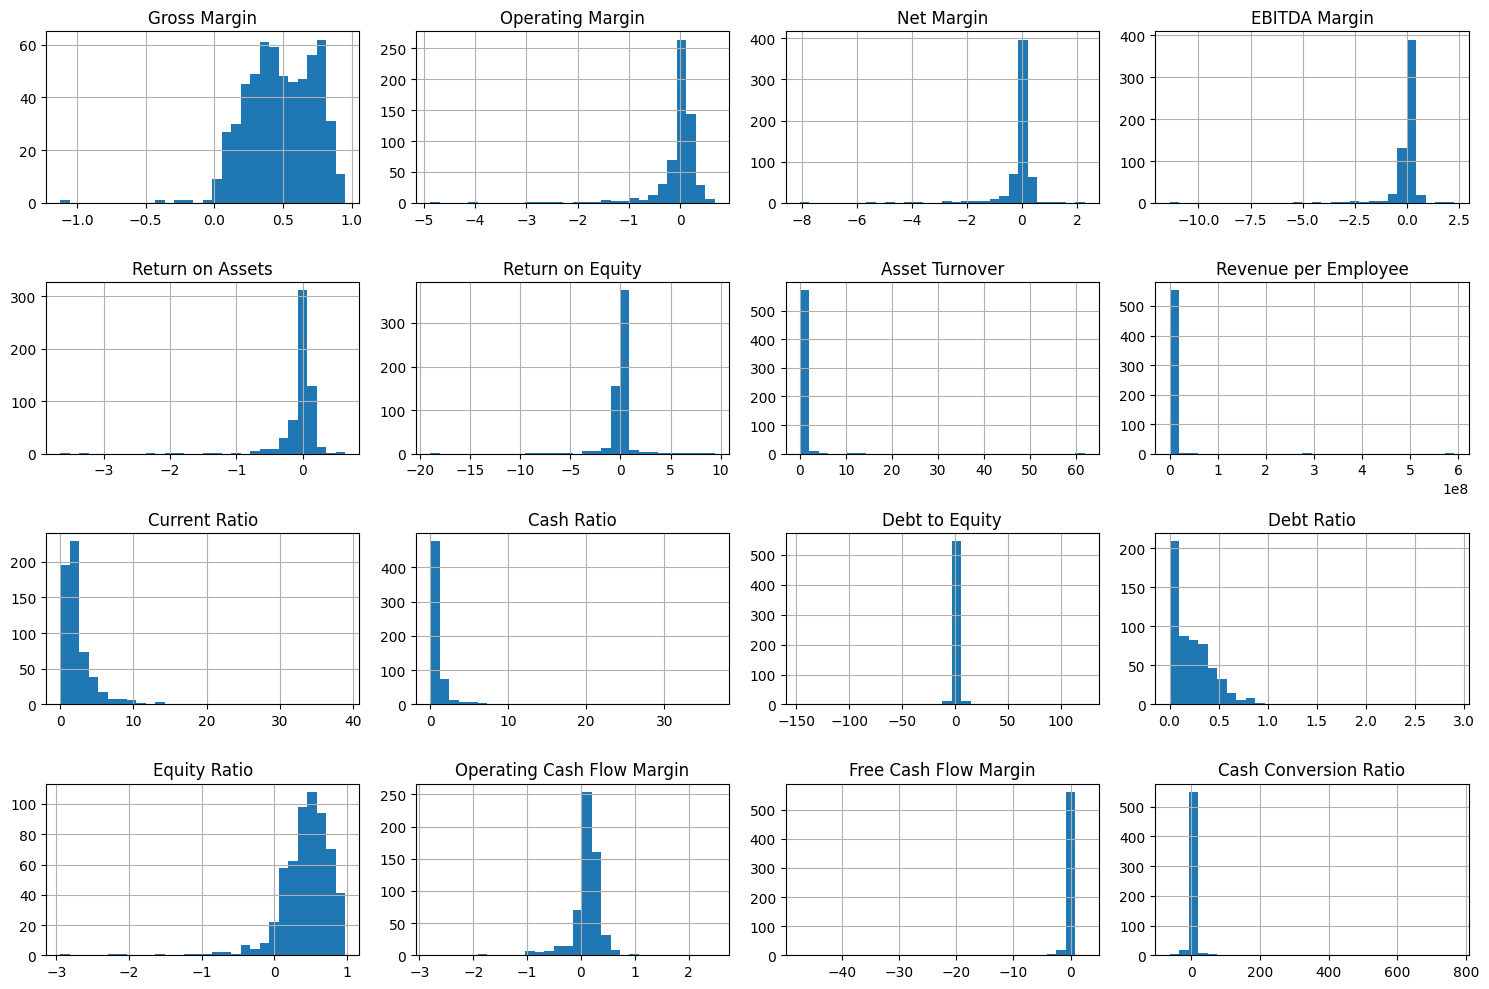

In [30]:
peer_universe_df[selected_clustering_kpis].hist(
    figsize=(15,10),
    bins=30
)
plt.tight_layout()

# **6. KPI Outlier Analysis**

### **6.1 Creating Boxplots**

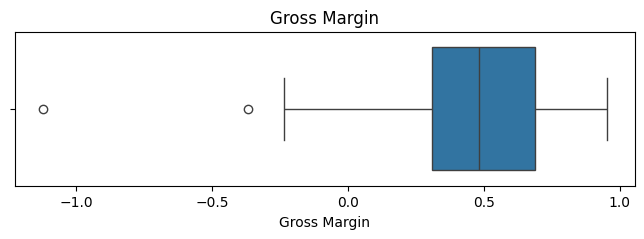

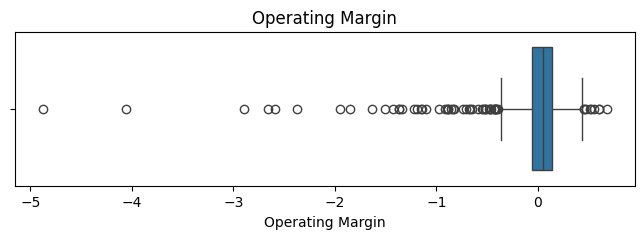

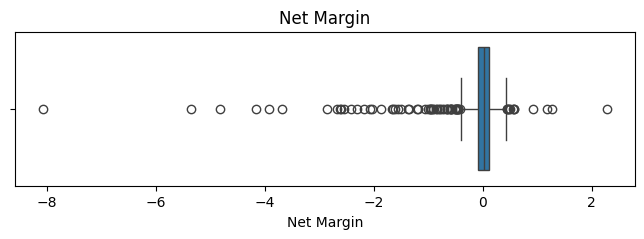

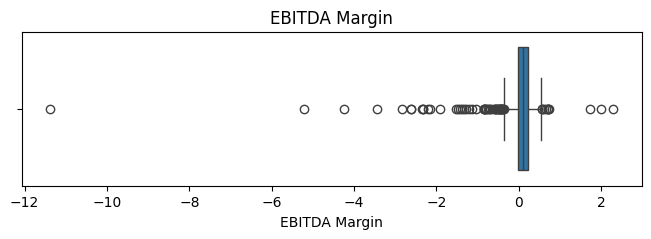

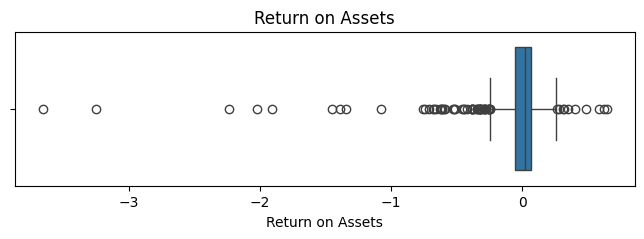

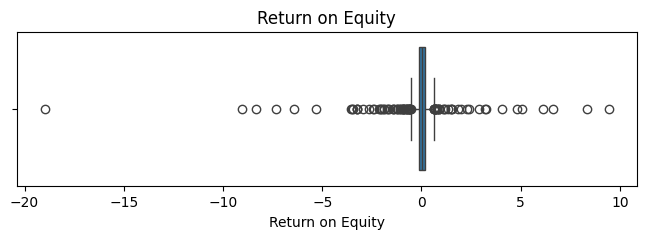

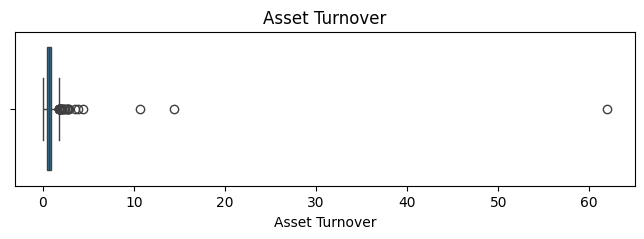

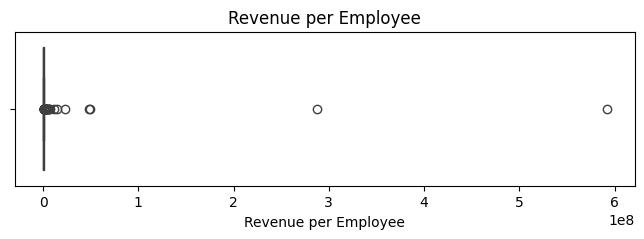

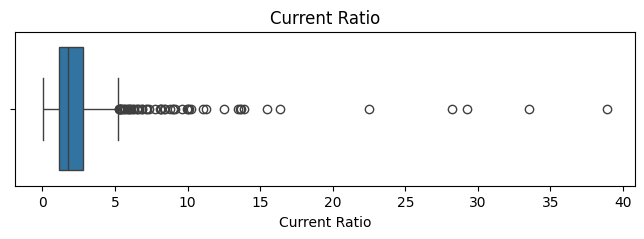

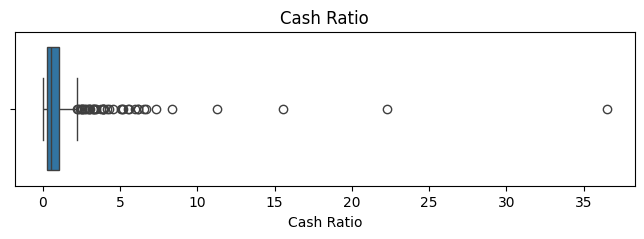

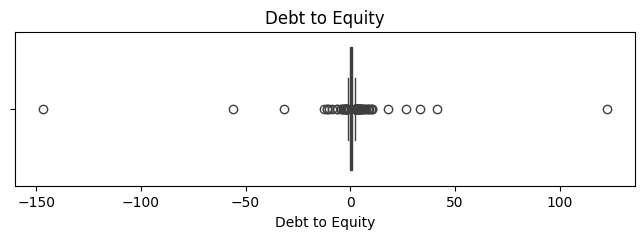

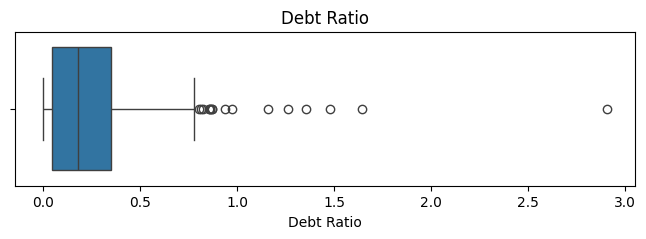

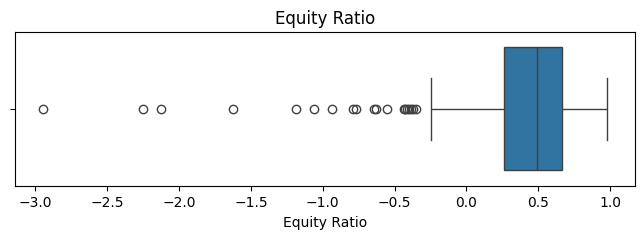

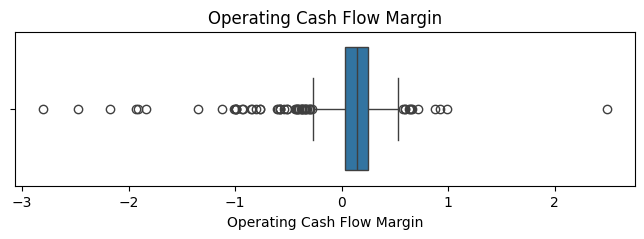

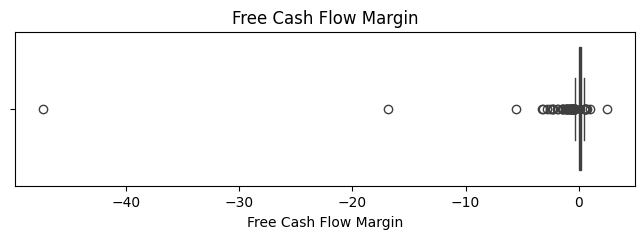

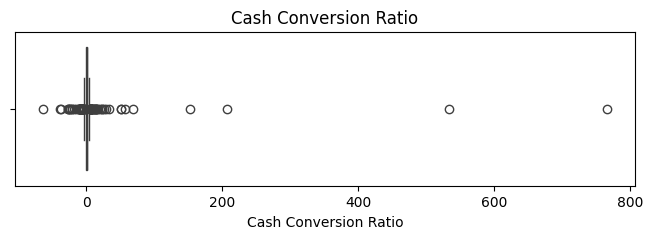

In [31]:
for kpi in selected_clustering_kpis:
    plt.figure(figsize=(8, 2))
    sns.boxplot(x=peer_universe_df[kpi])
    plt.title(kpi)
    plt.show()

There are so many outliers, that it's hard to see the data distribution

### **6.2 Impute missing KPIs**

In [32]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_imputed = imputer.fit_transform(
    peer_universe_df[selected_clustering_kpis]
)

imputed_features_df = pd.DataFrame(
    X_imputed,
    columns=selected_clustering_kpis,
    index=peer_universe_df.index
)

imputed_features_df.head()

,Gross Margin,Operating Margin,Net Margin,EBITDA Margin,Return on Assets,Return on Equity,Asset Turnover,Revenue per Employee,Current Ratio,Cash Ratio,Debt to Equity,Debt Ratio,Equity Ratio,Operating Cash Flow Margin,Free Cash Flow Margin,Cash Conversion Ratio
0,0.709952,0.044230,0.032562,0.055649,0.066434,0.088511,2.040244,2.625752e+06,3.758144,1.936742,0.078412,0.058854,0.750572,0.073452,0.058435,2.255776
1,0.487897,0.185595,0.157141,0.206236,0.212296,0.302832,1.350988,7.490348e+05,4.208129,1.958237,0.035236,0.024702,0.701035,0.225693,0.189299,1.436244
2,0.129065,-0.093689,-0.093748,-0.089977,-0.242287,-0.346627,2.584458,3.800006e+05,3.439537,0.879958,0.069397,0.048508,0.698984,-0.225362,-0.269679,2.403924
3,0.366376,-0.053240,-0.045365,-0.024887,-0.057235,-0.067080,1.261633,2.166639e+05,4.401152,2.658078,0.034154,0.029141,0.853231,-0.036855,-0.039725,0.812402
4,0.482275,-0.063035,-0.093401,-0.134339,-0.042559,-0.045887,0.455653,5.653535e+05,13.486890,0.670833,0.264777,0.181524,0.927456,-0.210290,-0.212487,2.251475


### **6.3 Clustering Feature Selection**

In [33]:
balanced_clustering_kpis = [
    "EBITDA Margin",
    "Return on Assets",
    "Asset Turnover",
    "Revenue per Employee",
    "Current Ratio",
    "Debt Ratio",
    "Free Cash Flow Margin",
    "Cash Conversion Ratio",
]

missing_balanced_kpis = [
    kpi for kpi in balanced_clustering_kpis
    if kpi not in selected_clustering_kpis
]

if missing_balanced_kpis:
    raise ValueError(
        f"The following balanced clustering KPIs are missing from the selected KPI set: "
        f"{missing_balanced_kpis}"
    )

print(f"Balanced clustering KPIs: {len(balanced_clustering_kpis)}")
balanced_clustering_kpis

Balanced clustering KPIs: 8


['EBITDA Margin',
 'Return on Assets',
 'Asset Turnover',
 'Revenue per Employee',
 'Current Ratio',
 'Debt Ratio',
 'Free Cash Flow Margin',
 'Cash Conversion Ratio']

In [34]:
# Build Balanced Feature Matrix

balanced_features_df = imputed_features_df[
    balanced_clustering_kpis
].copy()

balanced_features_df.head()

,EBITDA Margin,Return on Assets,Asset Turnover,Revenue per Employee,Current Ratio,Debt Ratio,Free Cash Flow Margin,Cash Conversion Ratio
0,0.055649,0.066434,2.040244,2.625752e+06,3.758144,0.058854,0.058435,2.255776
1,0.206236,0.212296,1.350988,7.490348e+05,4.208129,0.024702,0.189299,1.436244
2,-0.089977,-0.242287,2.584458,3.800006e+05,3.439537,0.048508,-0.269679,2.403924
3,-0.024887,-0.057235,1.261633,2.166639e+05,4.401152,0.029141,-0.039725,0.812402
4,-0.134339,-0.042559,0.455653,5.653535e+05,13.486890,0.181524,-0.212487,2.251475


### **6.4 Winzorization**

In [35]:
# Strong Winsorization for Clustering Features

def winsorize_series(series, lower=0.05, upper=0.95):
    lower_bound = series.quantile(lower)
    upper_bound = series.quantile(upper)

    return series.clip(
        lower=lower_bound,
        upper=upper_bound
    )

In [36]:
balanced_features_df = imputed_features_df[
    balanced_clustering_kpis
].copy()

balanced_winsorized_features_df = balanced_features_df.copy()

for kpi in balanced_clustering_kpis:
    balanced_winsorized_features_df[kpi] = winsorize_series(
        balanced_winsorized_features_df[kpi],
        lower=0.05,
        upper=0.95
    )

balanced_winsorized_features_df.describe().T

,count,mean,std,min,25%,50%,75%,max
EBITDA Margin,588.0,0.055283,0.266843,-0.717492,-0.015872,0.093541,0.211078,4.277354e-01
Return on Assets,588.0,-0.012752,0.140029,-0.383116,-0.056394,0.017972,0.067786,1.829171e-01
Asset Turnover,588.0,0.710181,0.402200,0.151636,0.413872,0.611594,0.935315,1.701135e+00
Revenue per Employee,588.0,550229.851134,483298.202133,108573.650725,265282.456622,380000.606283,618047.651501,2.040110e+06
Current Ratio,588.0,2.365061,1.730334,0.618711,1.148189,1.793978,2.776300,7.301735e+00
Debt Ratio,588.0,0.218591,0.185258,0.006131,0.047380,0.181524,0.344485,6.183062e-01
Free Cash Flow Margin,588.0,0.045801,0.237251,-0.639055,-0.013331,0.088529,0.187793,3.471780e-01
Cash Conversion Ratio,588.0,0.873917,2.900198,-6.268921,-0.091769,1.129946,1.990632,7.172117e+00


In [37]:
# ==================================================
# Business Rule Caps for Clustering Features
# ADDED THIS ONE AFTERWARDS

business_caps = {
    "EBITDA Margin": (-1.0, 1.0),
    "Free Cash Flow Margin": (-1.0, 1.0),
    "Return on Assets": (-1.0, 1.0),
    "Cash Conversion Ratio": (-5.0, 5.0),
    "Current Ratio": (0.0, 10.0),
    "Debt Ratio": (0.0, 2.0),
}

capped_features_df = balanced_winsorized_features_df.copy()

for kpi, (lower_cap, upper_cap) in business_caps.items():
    if kpi in capped_features_df.columns:
        capped_features_df[kpi] = capped_features_df[kpi].clip(
            lower=lower_cap,
            upper=upper_cap
        )

capped_features_df.describe().T

,count,mean,std,min,25%,50%,75%,max
EBITDA Margin,588.0,0.055283,0.266843,-0.717492,-0.015872,0.093541,0.211078,4.277354e-01
Return on Assets,588.0,-0.012752,0.140029,-0.383116,-0.056394,0.017972,0.067786,1.829171e-01
Asset Turnover,588.0,0.710181,0.402200,0.151636,0.413872,0.611594,0.935315,1.701135e+00
Revenue per Employee,588.0,550229.851134,483298.202133,108573.650725,265282.456622,380000.606283,618047.651501,2.040110e+06
Current Ratio,588.0,2.365061,1.730334,0.618711,1.148189,1.793978,2.776300,7.301735e+00
Debt Ratio,588.0,0.218591,0.185258,0.006131,0.047380,0.181524,0.344485,6.183062e-01
Free Cash Flow Margin,588.0,0.045801,0.237251,-0.639055,-0.013331,0.088529,0.187793,3.471780e-01
Cash Conversion Ratio,588.0,0.809765,2.440748,-5.000000,-0.091769,1.129946,1.990632,5.000000e+00


### **6.5 RobustScaler**

In [38]:
# Scale Balanced Winsorized Feature Matrix

from sklearn.preprocessing import RobustScaler

balanced_scaler = RobustScaler()

X_balanced_scaled = balanced_scaler.fit_transform(
    capped_features_df
)

balanced_model_features_df = pd.DataFrame(
    X_balanced_scaled,
    columns=balanced_clustering_kpis,
    index=balanced_winsorized_features_df.index
)

balanced_model_features_df.describe().T

,count,mean,std,min,25%,50%,75%,max
EBITDA Margin,588.0,-0.168576,1.175782,-3.573632,-0.482100,0.000000e+00,0.517900,1.472553
Return on Assets,588.0,-0.247413,1.127624,-3.229885,-0.598856,0.000000e+00,0.401144,1.328274
Asset Turnover,588.0,0.189065,0.771321,-0.882087,-0.379183,0.000000e+00,0.620817,2.089471
Revenue per Employee,588.0,0.482557,1.370028,-0.769427,-0.325197,0.000000e+00,0.674803,4.705990
Current Ratio,588.0,0.350764,1.062786,-0.721859,-0.396649,-6.808790e-17,0.603351,3.382913
Debt Ratio,588.0,0.124759,0.623543,-0.590340,-0.451502,0.000000e+00,0.548498,1.470128
Free Cash Flow Margin,588.0,-0.212443,1.179629,-3.617592,-0.506454,0.000000e+00,0.493546,1.286021
Cash Conversion Ratio,588.0,-0.153756,1.172084,-2.943692,-0.586686,0.000000e+00,0.413314,1.858459


In [39]:
# Check Scaled Feature Extremes

scaled_extremes = pd.DataFrame({
    "Min": balanced_model_features_df.min(),
    "Max": balanced_model_features_df.max(),
    "Max Absolute Value": balanced_model_features_df.abs().max()
}).sort_values(
    "Max Absolute Value",
    ascending=False
)

scaled_extremes

,Min,Max,Max Absolute Value
Revenue per Employee,-0.769427,4.705990,4.705990
Free Cash Flow Margin,-3.617592,1.286021,3.617592
EBITDA Margin,-3.573632,1.472553,3.573632
Current Ratio,-0.721859,3.382913,3.382913
Return on Assets,-3.229885,1.328274,3.229885
Cash Conversion Ratio,-2.943692,1.858459,2.943692
Asset Turnover,-0.882087,2.089471,2.089471
Debt Ratio,-0.590340,1.470128,1.470128


# **7. PCA Analysis**

### **7.1 Fit PCA**

In [40]:
from sklearn.decomposition import PCA

# ==================================================
# PCA on Strongly Winsorized Balanced Feature Set
# ==================================================

balanced_pca = PCA()

X_balanced_pca = balanced_pca.fit_transform(X_balanced_scaled)

balanced_explained_variance = pd.DataFrame({
    "Component": range(1, len(balanced_pca.explained_variance_ratio_) + 1),
    "Explained Variance": balanced_pca.explained_variance_ratio_,
    "Cumulative Variance": np.cumsum(balanced_pca.explained_variance_ratio_)
})

balanced_explained_variance

,Component,Explained Variance,Cumulative Variance
0,1,0.357841,0.357841
1,2,0.200461,0.558302
2,3,0.137276,0.695578
3,4,0.131653,0.827231
4,5,0.066986,0.894217
5,6,0.052088,0.946306
6,7,0.033244,0.979549
7,8,0.020451,1.000000


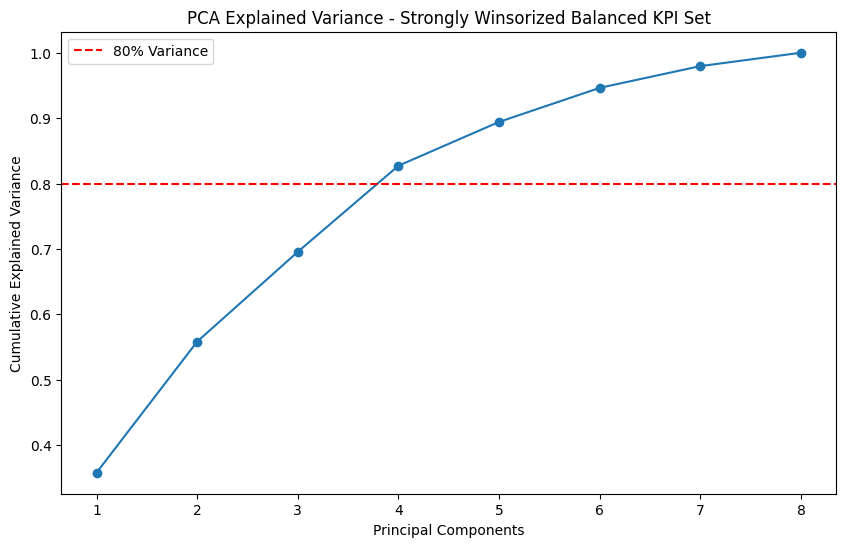

In [41]:
plt.figure(figsize=(10, 6))

plt.plot(
    balanced_explained_variance["Component"],
    balanced_explained_variance["Cumulative Variance"],
    marker="o"
)

plt.axhline(
    y=0.80,
    color="red",
    linestyle="--",
    label="80% Variance"
)

plt.xlabel("Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance - Strongly Winsorized Balanced KPI Set")
plt.legend()
plt.show()

In [42]:
balanced_pca_loadings = pd.DataFrame(
    balanced_pca.components_.T,
    index=balanced_clustering_kpis,
    columns=[f"PC{i+1}" for i in range(balanced_pca.n_components_)]
)

balanced_pca_loadings

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
EBITDA Margin,0.592417,-0.046561,-0.132492,-0.053925,-0.293134,0.162852,0.189327,0.691461
Return on Assets,0.547490,-0.045883,0.050870,-0.190020,-0.300276,0.354370,-0.231410,-0.624627
Asset Turnover,0.004794,0.124271,-0.145782,0.165639,0.591474,0.753047,0.135159,0.025627
Revenue per Employee,0.145524,0.970773,0.044028,0.109009,-0.039767,-0.136448,-0.046877,-0.014260
Current Ratio,-0.008608,0.072671,0.676739,-0.615594,0.165207,0.059696,0.352130,0.053494
Debt Ratio,-0.011680,0.007224,-0.176992,0.210883,-0.227296,-0.048520,0.872142,-0.330704
Free Cash Flow Margin,0.529831,-0.107580,-0.178591,-0.068119,0.626243,-0.505348,0.071792,-0.135868
Cash Conversion Ratio,0.217173,-0.144830,0.659902,0.702565,0.036708,-0.030153,-0.018932,0.013266


### **7.2 Scree Plot**

In [43]:
# N_COMPONENTS = 4

# pca = PCA(n_components=N_COMPONENTS)

# X_pca = pca.fit_transform(X_scaled)

# pca_df = pd.DataFrame(
#     X_pca,
#     columns=[
#         f"PC{i+1}"
#         for i in range(N_COMPONENTS)
#     ]
# )

# pca_df.head()

We lost the 'X_scaled' somewhere...

Old: PCA 1 overpowers the others, not good

In [44]:
# plot_df = peer_universe_df.copy()

# plot_df["PC1"] = X_pca[:, 0]
# plot_df["PC2"] = X_pca[:, 1]

# plt.figure(figsize=(10, 8))

# plt.scatter(
#     plot_df["PC1"],
#     plot_df["PC2"],
#     alpha=0.6
# )

# plt.xlabel("PC1")
# plt.ylabel("PC2")
# plt.title("PCA Projection")

# plt.show()

In [45]:
# pca_loadings = pd.DataFrame(
#     pca.components_.T,
#     index=selected_clustering_kpis,
#     columns=[f"PC{i+1}" for i in range(pca.n_components_)]
# )

# pca_loadings

In [46]:
# pca_loadings["PC1"].sort_values(
#     key=abs,
#     ascending=False
# )

Up until this point, PCA is dominated by profitability and cash flow... this is not necessarily wrong, as these features are genuinely important for benchmarking, but it's not the level of depth I'm trying to achieve for the clusters. We might need to create a category-balanced feature selection.

# **8. KPI Correlation Analysis**

### **8.1 Correlation Matrix**

In [47]:
correlation_matrix = balanced_winsorized_features_df[
    balanced_clustering_kpis
].corr()

correlation_matrix

,EBITDA Margin,Return on Assets,Asset Turnover,Revenue per Employee,Current Ratio,Debt Ratio,Free Cash Flow Margin,Cash Conversion Ratio
EBITDA Margin,1.000000,0.819909,-0.027818,0.112977,-0.076853,0.051887,0.671650,0.180553
Return on Assets,0.819909,1.000000,-0.051167,0.097366,0.095458,-0.102709,0.597794,0.184097
Asset Turnover,-0.027818,-0.051167,1.000000,0.167252,-0.168442,0.022250,0.057484,-0.013821
Revenue per Employee,0.112977,0.097366,0.167252,1.000000,0.048601,0.026897,0.037551,-0.026565
Current Ratio,-0.076853,0.095458,-0.168442,0.048601,1.000000,-0.372168,-0.061686,0.001673
Debt Ratio,0.051887,-0.102709,0.022250,0.026897,-0.372168,1.000000,-0.066261,0.026459
Free Cash Flow Margin,0.671650,0.597794,0.057484,0.037551,-0.061686,-0.066261,1.000000,0.155785
Cash Conversion Ratio,0.180553,0.184097,-0.013821,-0.026565,0.001673,0.026459,0.155785,1.000000


In [48]:
balanced_winsorized_features_df

,EBITDA Margin,Return on Assets,Asset Turnover,Revenue per Employee,Current Ratio,Debt Ratio,Free Cash Flow Margin,Cash Conversion Ratio
0,0.055649,0.066434,1.701135,2.040110e+06,3.758144,0.058854,0.058435,2.255776
1,0.206236,0.182917,1.350988,7.490348e+05,4.208129,0.024702,0.189299,1.436244
2,-0.089977,-0.242287,1.701135,3.800006e+05,3.439537,0.048508,-0.269679,2.403924
3,-0.024887,-0.057235,1.261633,2.166639e+05,4.401152,0.029141,-0.039725,0.812402
4,-0.134339,-0.042559,0.455653,5.653535e+05,7.301735,0.181524,-0.212487,2.251475
...,...,...,...,...,...,...,...,...
583,0.188336,0.060908,0.718231,3.987312e+05,1.070830,0.287023,0.119329,1.474664
584,0.339973,0.099458,0.281798,1.513739e+06,7.301735,0.006131,0.347178,1.049615
585,0.245456,0.083757,0.691104,2.728806e+05,1.006203,0.086177,0.347178,3.411732
586,-0.097456,-0.070937,0.458358,3.393145e+05,1.023291,0.405357,-0.102265,0.641210


### **8.2 Correlation Heatmap**

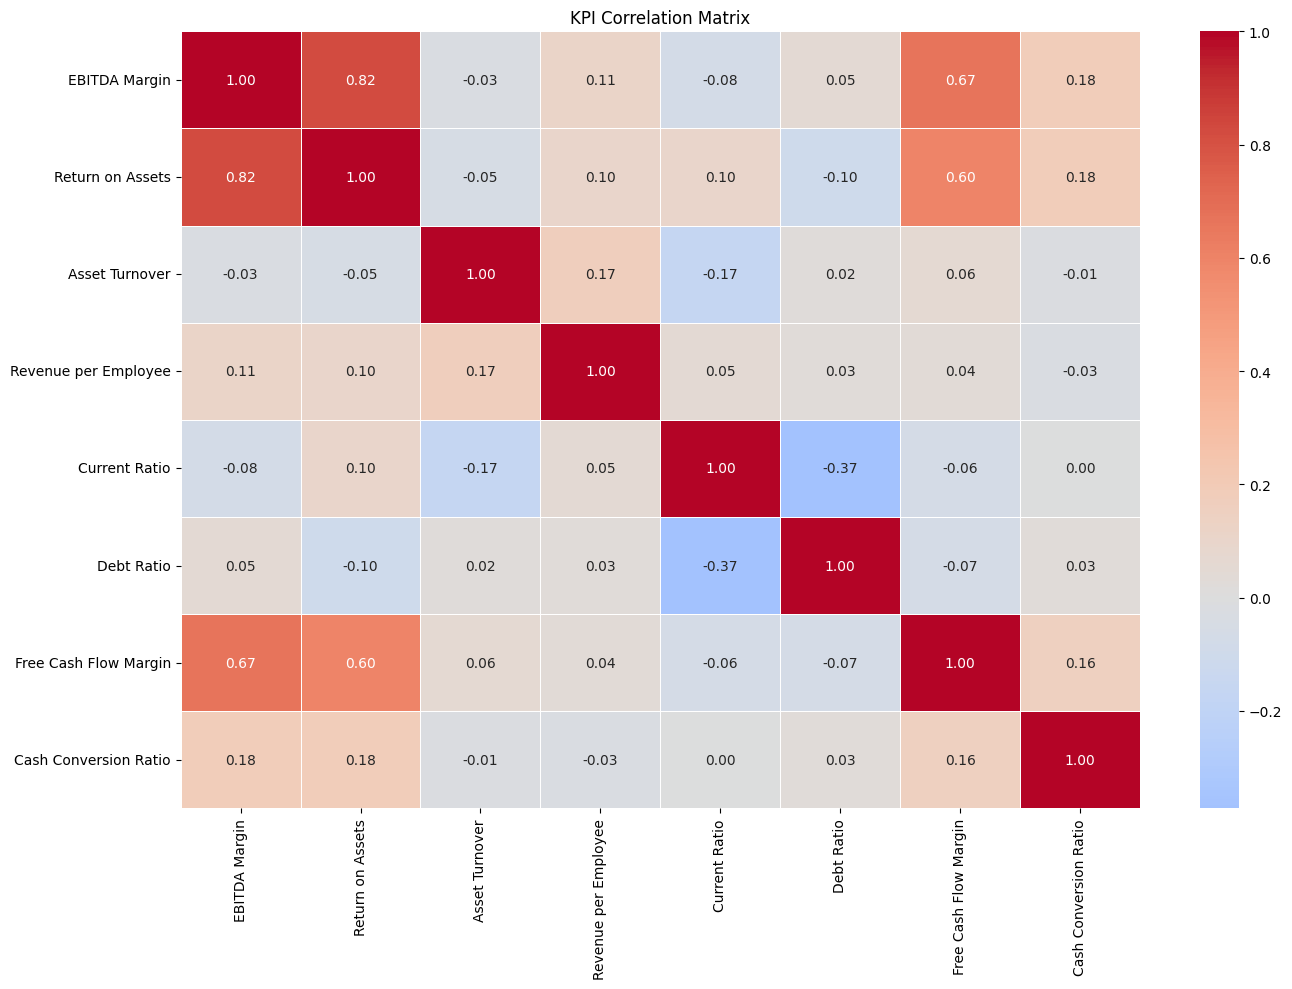

In [49]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("KPI Correlation Matrix")
plt.tight_layout()
plt.show()

### **8.3 Highly Correlated KPIs**

In [50]:
CORRELATION_THRESHOLD = 0.85

corr_pairs = (
    correlation_matrix
    .where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

corr_pairs.columns = ["KPI 1", "KPI 2", "Correlation"]

high_corr_pairs = corr_pairs[
    corr_pairs["Correlation"].abs() >= CORRELATION_THRESHOLD
].sort_values(
    by="Correlation",
    key=abs,
    ascending=False
)

high_corr_pairs

,KPI 1,KPI 2,Correlation


None, this is a good sign the previous scaling worked

### **8.4 Correlation by Category**

In [51]:
kpi_category_mapping = (
    kpi_definitions
    .set_index("KPI")["Category"]
    .to_dict()
)

correlation_category_summary = high_corr_pairs.copy()

correlation_category_summary["Category 1"] = correlation_category_summary["KPI 1"].map(
    kpi_category_mapping
)

correlation_category_summary["Category 2"] = correlation_category_summary["KPI 2"].map(
    kpi_category_mapping
)

correlation_category_summary

,KPI 1,KPI 2,Correlation,Category 1,Category 2


Same here

### **8.5 Average Absolute Correlation per KPI**

In [52]:
avg_abs_correlation = (
    correlation_matrix
    .abs()
    .replace(1, np.nan)
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

avg_abs_correlation.columns = [
    "KPI",
    "Average Absolute Correlation"
]

avg_abs_correlation

,KPI,Average Absolute Correlation
0,Return on Assets,0.278357
1,EBITDA Margin,0.277378
2,Free Cash Flow Margin,0.235459
3,Current Ratio,0.117840
4,Debt Ratio,0.095519
5,Cash Conversion Ratio,0.084136
6,Revenue per Employee,0.073887
7,Asset Turnover,0.072605


# **9. Clustering Experiments**

In [53]:
# Here we finally start with the clustering -> 7/2/2026

## **9.1 K-Means Baseline**

K-Means is used as the baseline clustering algorithm due to its simplicity, computational efficiency, and interpretability. The model is evaluated across a range of cluster counts using multiple internal validation metrics.

To ensure consistency with subsequent clustering experiments, K-Means is applied to the four-dimensional PCA representation of the balanced KPI feature space. These four principal components retain more than 80% of the total variance.

### 9.1.1 Prepare Clustering Input

In [54]:
# ==================================================
# Prepare Clustering Input
# ==================================================

N_COMPONENTS = 4

X_cluster = X_balanced_pca[:, :N_COMPONENTS]

print(f"Clustering input shape: {X_cluster.shape}")

Clustering input shape: (588, 4)


In [55]:
print(
    f"Cumulative variance retained: "
    f"{balanced_explained_variance.loc[N_COMPONENTS - 1, 'Cumulative Variance']:.2%}"
)

Cumulative variance retained: 82.72%


### 9.1.2 Evaluate Candidate Values of K

In [56]:
K_RANGE = range(2, 11)

In [57]:
# ==================================================
# Evaluate Candidate Values of K
# ==================================================

from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
)

K_RANGE = range(2, 11)

kmeans_results = []

for k in K_RANGE:

    model = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=50,
    )

    cluster_labels = model.fit_predict(X_cluster)

    kmeans_results.append({
        "Model": "K-Means",
        "K": k,
        "Inertia": model.inertia_,
        "Silhouette Score": silhouette_score(
            X_cluster,
            cluster_labels
        ),
        "Davies-Bouldin Index": davies_bouldin_score(
            X_cluster,
            cluster_labels
        ),
        "Calinski-Harabasz Score": calinski_harabasz_score(
            X_cluster,
            cluster_labels
        ),
    })

kmeans_results_df = pd.DataFrame(kmeans_results)

kmeans_results_df

,Model,K,Inertia,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Score
0,K-Means,2,3206.419707,0.319061,1.369437,249.046472
1,K-Means,3,2509.045790,0.348711,1.143806,240.160732
2,K-Means,4,1883.189369,0.349593,1.057253,277.647527
3,K-Means,5,1588.694517,0.366551,0.978495,273.430977
4,K-Means,6,1410.063611,0.362804,1.002467,260.779147
5,K-Means,7,1247.159813,0.370703,0.993112,257.927914
6,K-Means,8,1123.008618,0.316147,1.054260,254.259554
7,K-Means,9,1016.500830,0.320375,1.011666,252.947603
8,K-Means,10,948.131394,0.322486,1.017627,245.270329


### 9.1.3 Identify Best K by Metric

In [58]:
# ==================================================
# Best K by Evaluation Metric
# ==================================================

best_silhouette_k = (
    kmeans_results_df
    .loc[kmeans_results_df["Silhouette Score"].idxmax(), "K"]
)

best_davies_bouldin_k = (
    kmeans_results_df
    .loc[kmeans_results_df["Davies-Bouldin Index"].idxmin(), "K"]
)

best_calinski_harabasz_k = (
    kmeans_results_df
    .loc[kmeans_results_df["Calinski-Harabasz Score"].idxmax(), "K"]
)

print(f"Best K by Silhouette Score: {best_silhouette_k}")
print(f"Best K by Davies-Bouldin Index: {best_davies_bouldin_k}")
print(f"Best K by Calinski-Harabasz Score: {best_calinski_harabasz_k}")

Best K by Silhouette Score: 7
Best K by Davies-Bouldin Index: 5
Best K by Calinski-Harabasz Score: 4


### 9.1.4 Elbow Method

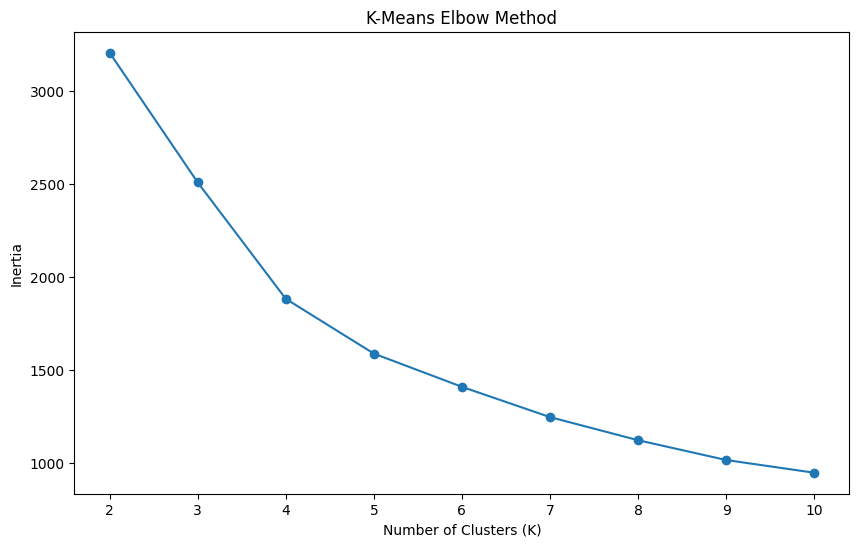

In [59]:
# ==================================================
# Elbow Method
# ==================================================

plt.figure(figsize=(10, 6))

plt.plot(
    kmeans_results_df["K"],
    kmeans_results_df["Inertia"],
    marker="o",
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("K-Means Elbow Method")
plt.xticks(list(K_RANGE))
plt.show()

### 9.1.5 Silhouette Score

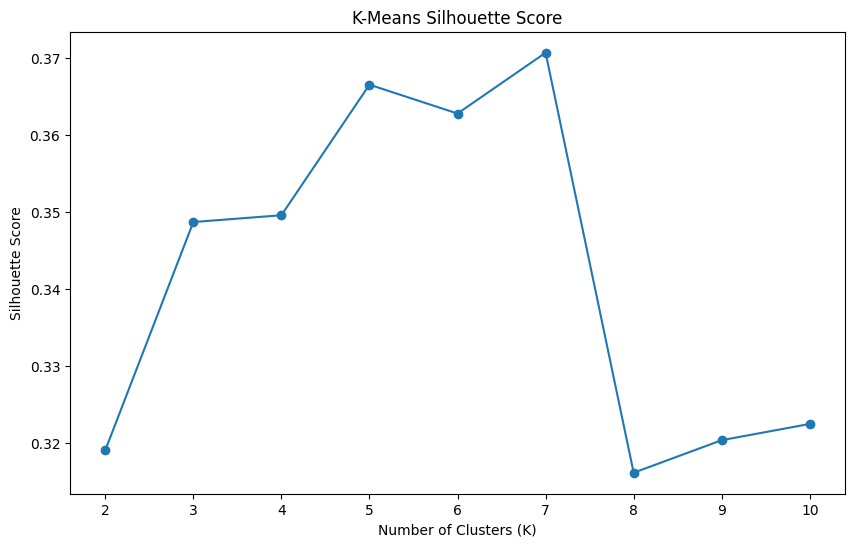

In [60]:
# ==================================================
# Silhouette Score
# ==================================================

plt.figure(figsize=(10, 6))

plt.plot(
    kmeans_results_df["K"],
    kmeans_results_df["Silhouette Score"],
    marker="o",
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("K-Means Silhouette Score")
plt.xticks(list(K_RANGE))
plt.show()

### 9.1.6 Davies-Bouldin Index

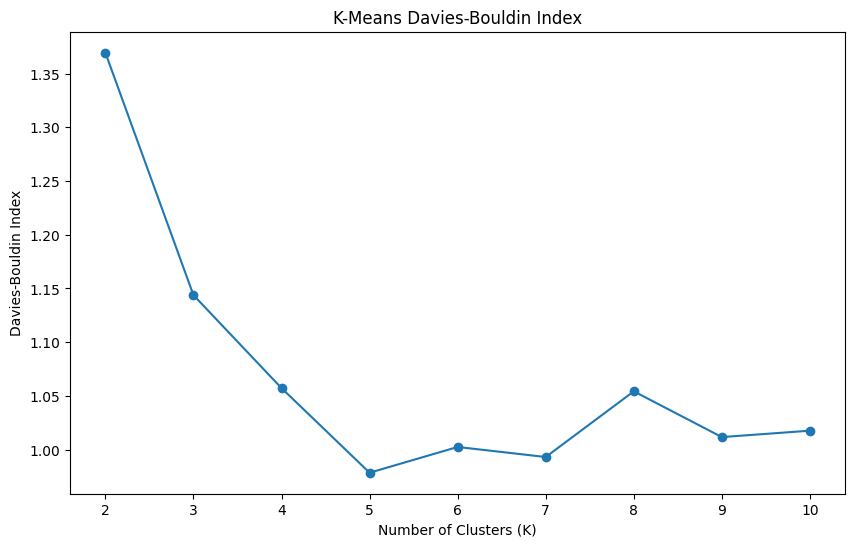

In [61]:
# ==================================================
# Davies-Bouldin Index
# ==================================================

plt.figure(figsize=(10, 6))

plt.plot(
    kmeans_results_df["K"],
    kmeans_results_df["Davies-Bouldin Index"],
    marker="o",
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Davies-Bouldin Index")
plt.title("K-Means Davies-Bouldin Index")
plt.xticks(list(K_RANGE))
plt.show()

### 9.1.7 Calinski-Harabasz Score

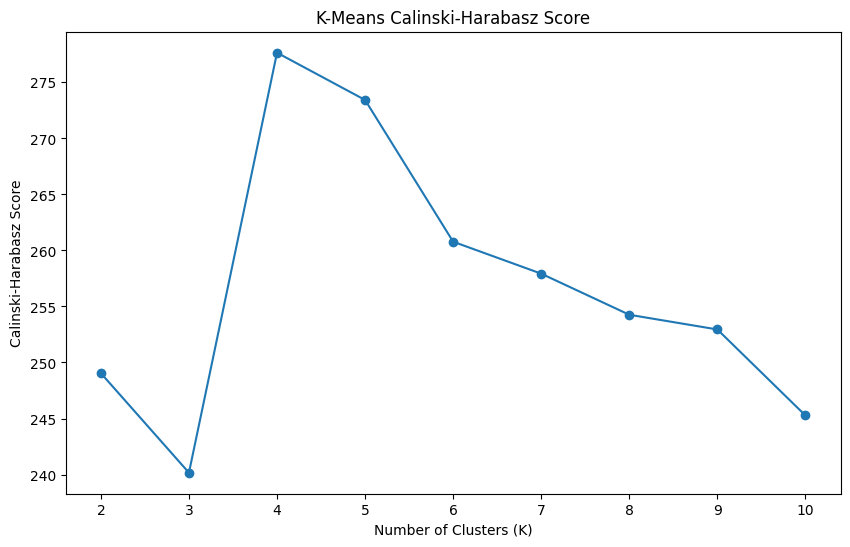

In [62]:
# ==================================================
# Calinski-Harabasz Score
# ==================================================

plt.figure(figsize=(10, 6))

plt.plot(
    kmeans_results_df["K"],
    kmeans_results_df["Calinski-Harabasz Score"],
    marker="o",
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Calinski-Harabasz Score")
plt.title("K-Means Calinski-Harabasz Score")
plt.xticks(list(K_RANGE))
plt.show()

### 9.1.8 Candidate K Comparison

In [63]:
# ==================================================
# Compare Candidate K Solutions
# ==================================================

candidate_k_values = [4, 5, 7]

candidate_cluster_results = {}

for k in candidate_k_values:
    model = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=50,
    )

    labels = model.fit_predict(X_cluster)

    candidate_cluster_results[k] = {
        "model": model,
        "labels": labels,
    }

    cluster_sizes = (
        pd.Series(labels)
        .value_counts()
        .sort_index()
    )

    print(f"\nK = {k}")
    print(cluster_sizes)


K = 4
0    292
1     71
2     65
3    160
Name: count, dtype: int64



K = 5
0     71
1     51
2    157
3     61
4    248
Name: count, dtype: int64



K = 7
0     52
1    245
2     69
3     46
4     50
5    109
6     17
Name: count, dtype: int64


In [64]:
# ==================================================
# Candidate Cluster Size Summary
# ==================================================

cluster_size_records = []

for k, result in candidate_cluster_results.items():

    cluster_sizes = (
        pd.Series(result["labels"])
        .value_counts()
        .sort_index()
    )

    for cluster, size in cluster_sizes.items():
        cluster_size_records.append({
            "K": k,
            "Cluster": cluster,
            "Company Count": size,
            "Cluster Share": size / len(X_cluster),
        })

cluster_size_summary_df = pd.DataFrame(cluster_size_records)

cluster_size_summary_df

,K,Cluster,Company Count,Cluster Share
0,4,0,292,0.496599
1,4,1,71,0.120748
2,4,2,65,0.110544
3,4,3,160,0.272109
4,5,0,71,0.120748
5,5,1,51,0.086735
6,5,2,157,0.267007
7,5,3,61,0.103741
8,5,4,248,0.421769
9,7,0,52,0.088435


In [65]:
cluster_balance_summary = (
    cluster_size_summary_df
    .groupby("K")
    .agg(
        Smallest_Cluster=("Company Count", "min"),
        Largest_Cluster=("Company Count", "max"),
        Smallest_Share=("Cluster Share", "min"),
        Largest_Share=("Cluster Share", "max"),
    )
)

cluster_balance_summary

,Smallest_Cluster,Largest_Cluster,Smallest_Share,Largest_Share
K,,,,
4,65,292,0.110544,0.496599
5,51,248,0.086735,0.421769
7,17,245,0.028912,0.416667


The largest cluster contains about half the companies, but the remaining three clusters are all large enough to support stable benchmark quartiles. A 65-company cluster is still perfectly usable.
K = 5 now looks like the strongest compromise between:

statistical performance + cluster balance + benchmark usability + interpretability

### 9.1.9 Candidate Cluster Profile Comparison

Candidate K-Means solutions are compared using the median values of the balanced clustering KPIs within each cluster. Median values are used instead of means because financial KPI distributions remain skewed even after preprocessing.

These profiles help determine whether additional clusters represent genuinely distinct financial archetypes or merely divide similar groups into smaller segments.

In [66]:
# ==================================================
# Build Candidate Cluster Profiles
# ==================================================

candidate_cluster_profiles_with_counts = {}

for k, profile in candidate_cluster_profiles_with_counts.items():

    cluster_sizes = (
        pd.Series(candidate_cluster_results[k]["labels"])
        .value_counts()
        .sort_index()
        .rename("Company Count")
    )

    profile_with_counts = profile.copy()

    profile_with_counts.insert(
        0,
        "Company Count",
        cluster_sizes
    )

    candidate_cluster_profiles_with_counts[k] = profile_with_counts

    print(f"\nK = {k}")
    display(profile_with_counts)

In [67]:
# ==================================================
# Standardised Candidate Cluster Profiles
# ==================================================

candidate_standardised_profiles = {}

for k, result in candidate_cluster_results.items():

    scaled_profile_df = balanced_model_features_df.copy()
    scaled_profile_df["Cluster"] = result["labels"]

    standardised_profile = (
        scaled_profile_df
        .groupby("Cluster")[balanced_clustering_kpis]
        .median()
    )

    candidate_standardised_profiles[k] = standardised_profile

    print(f"\nK = {k}")
    display(standardised_profile)


K = 4


,EBITDA Margin,Return on Assets,Asset Turnover,Revenue per Employee,Current Ratio,Debt Ratio,Free Cash Flow Margin,Cash Conversion Ratio
Cluster,,,,,,,,
0,0.412884,0.300174,-0.034259,-0.028002,0.015060,0.000000,0.295455,0.361332
1,-2.836556,-2.742502,-0.223246,-0.203253,0.123662,-0.161247,-2.524256,-0.356207
2,0.279532,0.342853,0.441232,3.985499,0.098999,-0.066051,0.088860,0.055279
3,-0.390394,-0.516687,0.097704,-0.022537,-0.054214,0.023336,-0.231549,-1.142728



K = 5


,EBITDA Margin,Return on Assets,Asset Turnover,Revenue per Employee,Current Ratio,Debt Ratio,Free Cash Flow Margin,Cash Conversion Ratio
Cluster,,,,,,,,
0,-2.836556,-2.742502,-0.223246,-0.203253,0.123662,-0.161247,-2.524256,-0.356207
1,0.191252,0.320401,-0.268872,0.398471,2.879457,-0.527834,0.292335,0.147089
2,-0.383510,-0.526184,0.120210,-0.020463,-0.062553,0.030546,-0.230322,-1.132829
3,0.209824,0.326107,0.502948,4.062406,-0.054431,0.000000,-0.065661,0.055279
4,0.429811,0.303633,0.004416,-0.057944,-0.122102,0.106809,0.305440,0.374699



K = 7


,EBITDA Margin,Return on Assets,Asset Turnover,Revenue per Employee,Current Ratio,Debt Ratio,Free Cash Flow Margin,Cash Conversion Ratio
Cluster,,,,,,,,
0,0.363339,0.390704,0.514737,3.949638,0.107372,0.000000,0.212928,0.120883
1,0.436608,0.305983,0.000000,-0.060399,-0.129808,0.127143,0.312306,0.369474
2,-0.233946,-0.290646,0.048892,0.041921,0.074453,0.000000,0.073936,-2.943692
3,-3.573632,-2.893255,-0.345790,-0.361725,0.149845,-0.166066,-3.411856,-0.338373
4,0.191862,0.347472,-0.240431,0.377407,2.889256,-0.532103,0.296495,0.145665
5,-0.639417,-0.913526,0.220894,-0.060499,-0.134639,0.062639,-0.493822,-0.624244
6,-1.354693,-1.794776,0.512182,4.705990,-0.075618,-0.071644,-1.221703,-0.421175


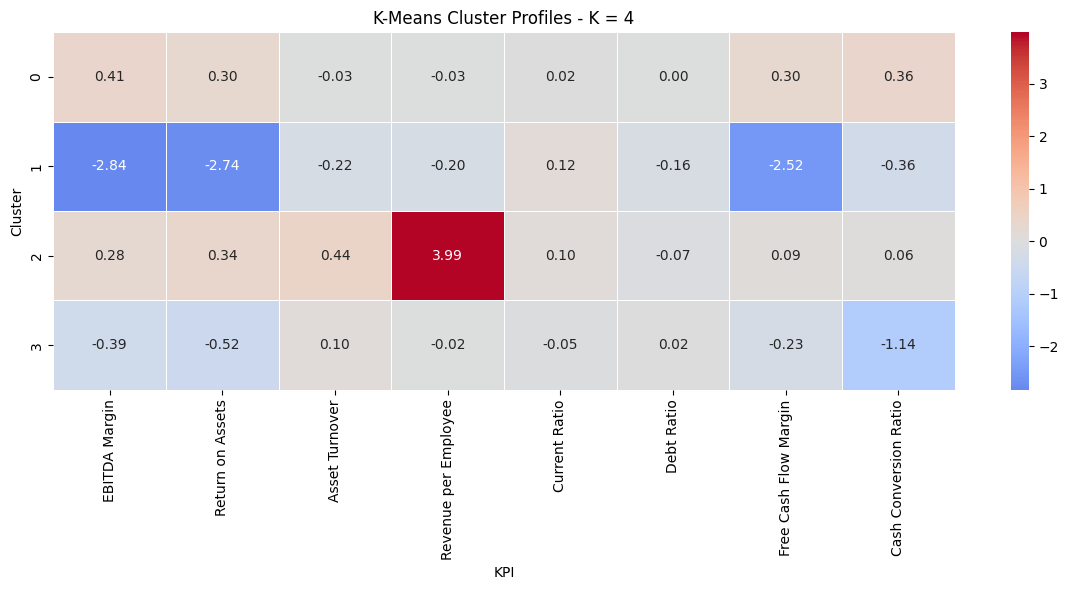

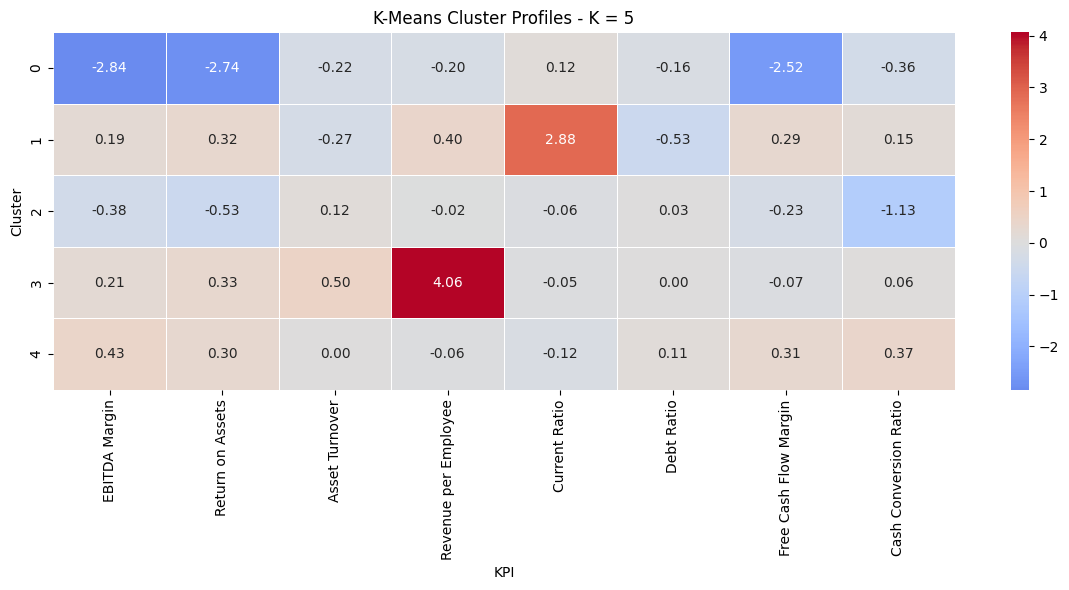

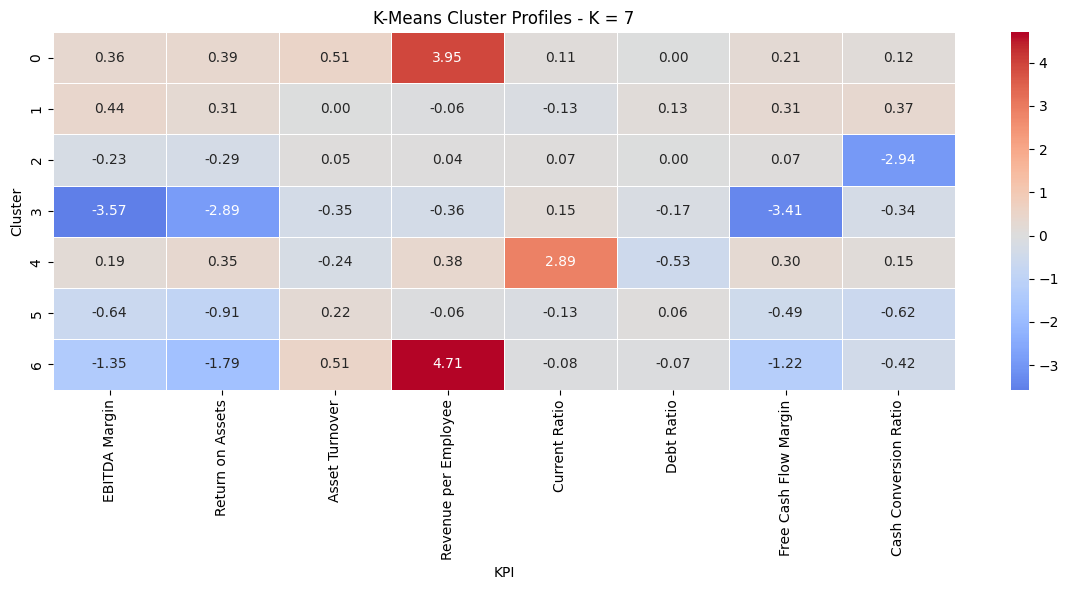

In [68]:
# ==================================================
# Candidate Cluster Profile Heatmaps
# ==================================================

for k, profile in candidate_standardised_profiles.items():

    plt.figure(figsize=(12, 6))

    sns.heatmap(
        profile,
        annot=True,
        fmt=".2f",
        center=0,
        cmap="coolwarm",
        linewidths=0.5
    )

    plt.title(f"K-Means Cluster Profiles - K = {k}")
    plt.xlabel("KPI")
    plt.ylabel("Cluster")
    plt.tight_layout()
    plt.show()

Ideal amount of clusters for K-Means baseline = 5

## **9.2 Agglomerative Clustering**

Agglomerative Clustering is evaluated as a hierarchical alternative to K-Means. Unlike centroid-based methods, it progressively merges similar observations based on pairwise distances, allowing the underlying hierarchical structure of the peer universe to influence cluster formation.

To ensure a fair comparison with the K-Means baseline, the method is applied to the same four-component PCA representation and evaluated using the same internal validation metrics.

### 9.2.1 Evaluate Candidate Cluster Counts

In [69]:
# ==================================================
# Evaluate Agglomerative Clustering
# ==================================================

from sklearn.cluster import AgglomerativeClustering

agglomerative_results = []

for k in K_RANGE:

    model = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward",
    )

    cluster_labels = model.fit_predict(X_cluster)

    agglomerative_results.append({
        "Model": "Agglomerative",
        "K": k,
        "Silhouette Score": silhouette_score(
            X_cluster,
            cluster_labels
        ),
        "Davies-Bouldin Index": davies_bouldin_score(
            X_cluster,
            cluster_labels
        ),
        "Calinski-Harabasz Score": calinski_harabasz_score(
            X_cluster,
            cluster_labels
        ),
    })

agglomerative_results_df = pd.DataFrame(
    agglomerative_results
)

agglomerative_results_df

,Model,K,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Score
0,Agglomerative,2,0.295106,1.450031,208.256556
1,Agglomerative,3,0.345746,1.152500,234.977396
2,Agglomerative,4,0.341366,1.055563,257.013876
3,Agglomerative,5,0.346407,1.019320,242.868826
4,Agglomerative,6,0.353685,1.007341,228.690932
5,Agglomerative,7,0.339207,0.986033,222.339384
6,Agglomerative,8,0.343959,1.058845,223.044428
7,Agglomerative,9,0.303126,1.178190,216.461226
8,Agglomerative,10,0.282523,1.154307,212.573454


### 9.2.2 Identify Best K by Metric

In [70]:
# ==================================================
# Best K by Evaluation Metric
# ==================================================

best_agg_silhouette_k = (
    agglomerative_results_df
    .loc[
        agglomerative_results_df["Silhouette Score"].idxmax(),
        "K"
    ]
)

best_agg_davies_bouldin_k = (
    agglomerative_results_df
    .loc[
        agglomerative_results_df["Davies-Bouldin Index"].idxmin(),
        "K"
    ]
)

best_agg_calinski_harabasz_k = (
    agglomerative_results_df
    .loc[
        agglomerative_results_df["Calinski-Harabasz Score"].idxmax(),
        "K"
    ]
)

print(
    f"Best K by Silhouette Score: "
    f"{best_agg_silhouette_k}"
)

print(
    f"Best K by Davies-Bouldin Index: "
    f"{best_agg_davies_bouldin_k}"
)

print(
    f"Best K by Calinski-Harabasz Score: "
    f"{best_agg_calinski_harabasz_k}"
)

Best K by Silhouette Score: 6
Best K by Davies-Bouldin Index: 7
Best K by Calinski-Harabasz Score: 4


### 9.2.3 Silhouette Score

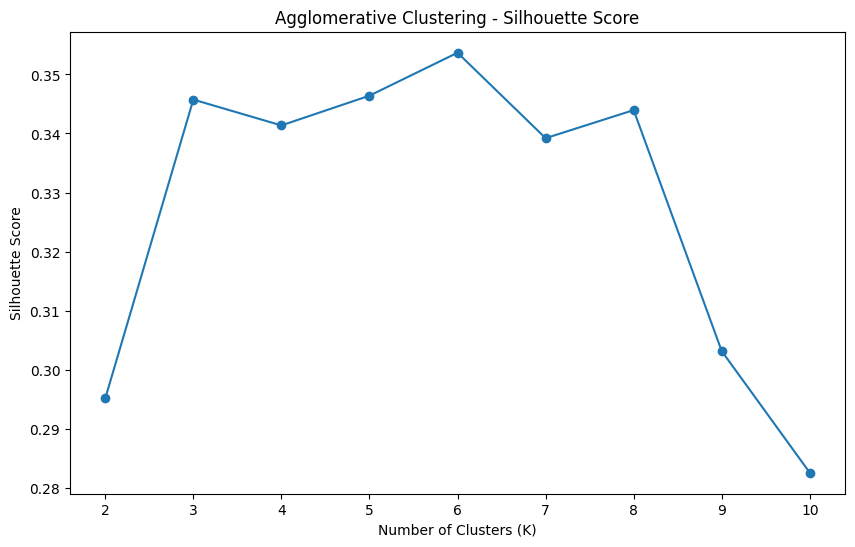

In [71]:
# ==================================================
# Silhouette Score
# ==================================================

plt.figure(figsize=(10, 6))

plt.plot(
    agglomerative_results_df["K"],
    agglomerative_results_df["Silhouette Score"],
    marker="o",
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Agglomerative Clustering - Silhouette Score")
plt.xticks(list(K_RANGE))
plt.show()

### 9.2.4 Davies-Bouldin Index

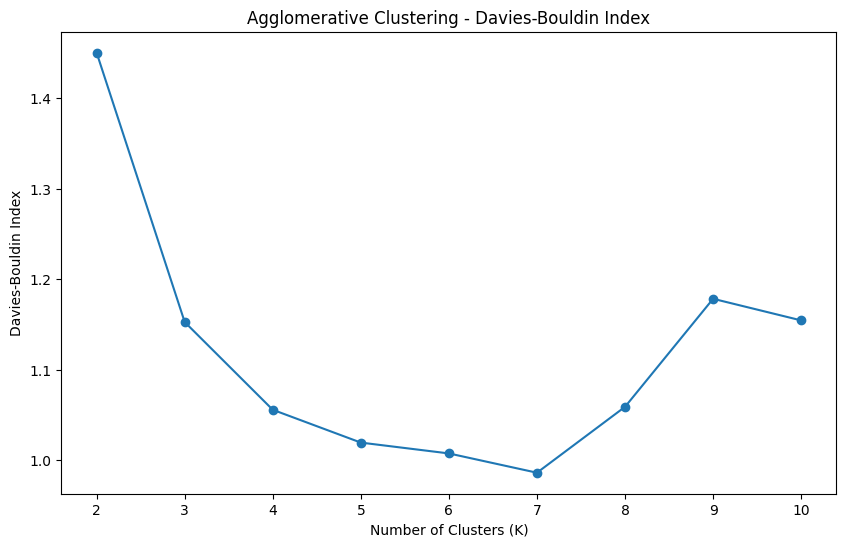

In [72]:
# ==================================================
# Davies-Bouldin Index
# ==================================================

plt.figure(figsize=(10, 6))

plt.plot(
    agglomerative_results_df["K"],
    agglomerative_results_df["Davies-Bouldin Index"],
    marker="o",
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Davies-Bouldin Index")
plt.title("Agglomerative Clustering - Davies-Bouldin Index")
plt.xticks(list(K_RANGE))
plt.show()

### 9.2.5 Calinski-Harabasz Score

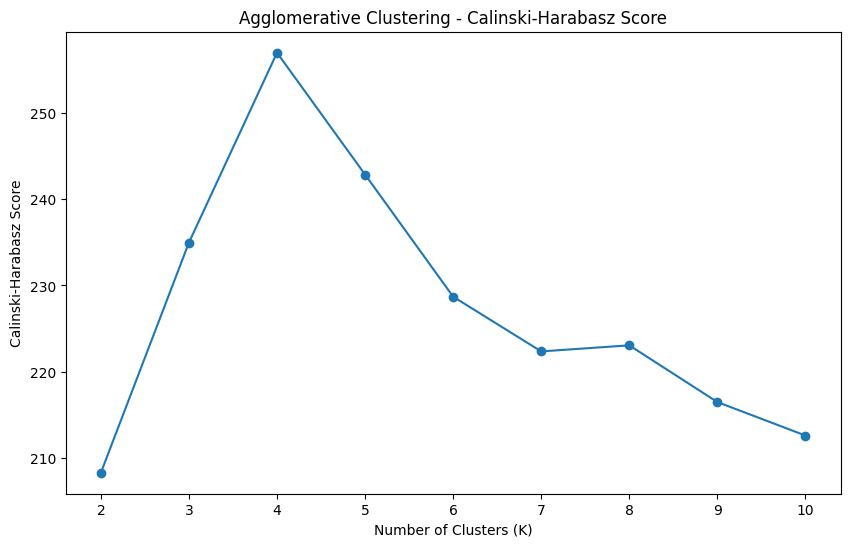

In [73]:
# ==================================================
# Calinski-Harabasz Score
# ==================================================

plt.figure(figsize=(10, 6))

plt.plot(
    agglomerative_results_df["K"],
    agglomerative_results_df["Calinski-Harabasz Score"],
    marker="o",
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Calinski-Harabasz Score")
plt.title("Agglomerative Clustering - Calinski-Harabasz Score")
plt.xticks(list(K_RANGE))
plt.show()

### 9.2.6 Compare Directly Against K-Means

In [74]:
# ==================================================
# Compare K-Means and Agglomerative Results
# ==================================================

traditional_model_comparison_df = pd.concat([
    kmeans_results_df[
        [
            "Model",
            "K",
            "Silhouette Score",
            "Davies-Bouldin Index",
            "Calinski-Harabasz Score",
        ]
    ],
    agglomerative_results_df,
], ignore_index=True)

traditional_model_comparison_df

,Model,K,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Score
0,K-Means,2,0.319061,1.369437,249.046472
1,K-Means,3,0.348711,1.143806,240.160732
2,K-Means,4,0.349593,1.057253,277.647527
3,K-Means,5,0.366551,0.978495,273.430977
4,K-Means,6,0.362804,1.002467,260.779147
5,K-Means,7,0.370703,0.993112,257.927914
6,K-Means,8,0.316147,1.054260,254.259554
7,K-Means,9,0.320375,1.011666,252.947603
8,K-Means,10,0.322486,1.017627,245.270329
9,Agglomerative,2,0.295106,1.450031,208.256556


In [75]:
# ==================================================
# Best Configuration per Algorithm
# ==================================================

best_configurations = pd.DataFrame([
    {
        "Model": "K-Means",
        "Best Silhouette K": best_silhouette_k,
        "Best DBI K": best_davies_bouldin_k,
        "Best CH K": best_calinski_harabasz_k,
    },
    {
        "Model": "Agglomerative",
        "Best Silhouette K": best_agg_silhouette_k,
        "Best DBI K": best_agg_davies_bouldin_k,
        "Best CH K": best_agg_calinski_harabasz_k,
    },
])

best_configurations

,Model,Best Silhouette K,Best DBI K,Best CH K
0,K-Means,7,5,4
1,Agglomerative,6,7,4


In [76]:
# ==================================================
# Agglomerative Candidate Solutions
# ==================================================

agg_candidate_k_values = [4, 6, 7]

agg_candidate_cluster_results = {}

for k in agg_candidate_k_values:

    model = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward",
    )

    labels = model.fit_predict(X_cluster)

    agg_candidate_cluster_results[k] = {
        "model": model,
        "labels": labels,
    }

    cluster_sizes = (
        pd.Series(labels)
        .value_counts()
        .sort_index()
    )

    print(f"\nK = {k}")
    print(cluster_sizes)


K = 4
0    303
1     69
2     61
3    155
Name: count, dtype: int64

K = 6
0    155
1    262
2     61
3     32
4     41
5     37
Name: count, dtype: int64

K = 7
0     61
1    262
2    108
3     32
4     41
5     37
6     47
Name: count, dtype: int64


### 9.2.7 Candidate Cluster Profile Comparison

Candidate Agglomerative Clustering solutions are compared using the median values of the balanced clustering KPIs within each cluster. As with the K-Means baseline, both raw KPI medians and standardised cluster profiles are examined to assess whether additional clusters reveal genuinely distinct financial archetypes.

In [77]:
# ==================================================
# Build Agglomerative Candidate Cluster Profiles
# ==================================================

agg_candidate_k_values = [4, 6, 7]

agg_candidate_cluster_results = {}

for k in agg_candidate_k_values:

    model = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward",
    )

    labels = model.fit_predict(X_cluster)

    agg_candidate_cluster_results[k] = {
        "model": model,
        "labels": labels,
    }

agg_candidate_cluster_profiles = {}

for k, result in agg_candidate_cluster_results.items():

    profile_df = peer_universe_df.copy()
    profile_df["Cluster"] = result["labels"]

    cluster_profile = (
        profile_df
        .groupby("Cluster")[balanced_clustering_kpis]
        .median()
    )

    agg_candidate_cluster_profiles[k] = cluster_profile

    print(f"\nK = {k}")
    display(cluster_profile)


K = 4


,EBITDA Margin,Return on Assets,Asset Turnover,Revenue per Employee,Current Ratio,Debt Ratio,Free Cash Flow Margin,Cash Conversion Ratio
Cluster,,,,,,,,
0,0.191174,0.057743,0.593730,3.701225e+05,1.800306,0.180540,0.152648,1.839595
1,-0.445817,-0.281418,0.447391,2.573457e+05,2.626396,0.110365,-0.388299,0.420272
2,0.055649,0.024165,0.884521,1.979221e+06,1.705358,0.194676,0.025991,0.877259
3,0.004941,-0.048548,0.681026,3.621543e+05,1.659286,0.200134,0.045970,-1.204523



K = 6


,EBITDA Margin,Return on Assets,Asset Turnover,Revenue per Employee,Current Ratio,Debt Ratio,Free Cash Flow Margin,Cash Conversion Ratio
Cluster,,,,,,,,
0,0.004941,-0.048548,0.681026,3.621543e+05,1.659286,0.200134,0.045970,-1.204523
1,0.191086,0.057727,0.616199,3.629565e+05,1.595182,0.215030,0.151646,1.871157
2,0.055649,0.024165,0.884521,1.979221e+06,1.705358,0.194676,0.025991,0.877259
3,-0.310246,-0.100547,0.368610,2.717425e+05,5.244454,0.041885,-0.296773,0.383032
4,0.192153,0.057759,0.478709,4.145614e+05,6.482053,0.022165,0.161175,1.569946
5,-0.697904,-0.524118,0.567417,2.443098e+05,1.227205,0.259063,-0.435338,0.472094



K = 7


,EBITDA Margin,Return on Assets,Asset Turnover,Revenue per Employee,Current Ratio,Debt Ratio,Free Cash Flow Margin,Cash Conversion Ratio
Cluster,,,,,,,,
0,0.055649,0.024165,0.884521,1.979221e+06,1.705358,0.194676,0.025991,0.877259
1,0.191086,0.057727,0.616199,3.629565e+05,1.595182,0.215030,0.151646,1.871157
2,-0.023554,-0.080649,0.727645,3.338740e+05,1.583716,0.208323,0.013811,-0.584377
3,-0.310246,-0.100547,0.368610,2.717425e+05,5.244454,0.041885,-0.296773,0.383032
4,0.192153,0.057759,0.478709,4.145614e+05,6.482053,0.022165,0.161175,1.569946
5,-0.697904,-0.524118,0.567417,2.443098e+05,1.227205,0.259063,-0.435338,0.472094
6,0.041133,-0.016942,0.637089,4.371535e+05,1.976053,0.156934,0.127079,-6.862472


In [78]:
# ==================================================
# Add Cluster Sizes to Agglomerative Profiles
# ==================================================

agg_candidate_cluster_profiles_with_counts = {}

for k, profile in agg_candidate_cluster_profiles.items():

    cluster_sizes = (
        pd.Series(agg_candidate_cluster_results[k]["labels"])
        .value_counts()
        .sort_index()
        .rename("Company Count")
    )

    profile_with_counts = profile.copy()

    profile_with_counts.insert(
        0,
        "Company Count",
        cluster_sizes
    )

    agg_candidate_cluster_profiles_with_counts[k] = profile_with_counts

    print(f"\nK = {k}")
    display(profile_with_counts)


K = 4


,Company Count,EBITDA Margin,Return on Assets,Asset Turnover,Revenue per Employee,Current Ratio,Debt Ratio,Free Cash Flow Margin,Cash Conversion Ratio
Cluster,,,,,,,,,
0,303,0.191174,0.057743,0.593730,3.701225e+05,1.800306,0.180540,0.152648,1.839595
1,69,-0.445817,-0.281418,0.447391,2.573457e+05,2.626396,0.110365,-0.388299,0.420272
2,61,0.055649,0.024165,0.884521,1.979221e+06,1.705358,0.194676,0.025991,0.877259
3,155,0.004941,-0.048548,0.681026,3.621543e+05,1.659286,0.200134,0.045970,-1.204523



K = 6


,Company Count,EBITDA Margin,Return on Assets,Asset Turnover,Revenue per Employee,Current Ratio,Debt Ratio,Free Cash Flow Margin,Cash Conversion Ratio
Cluster,,,,,,,,,
0,155,0.004941,-0.048548,0.681026,3.621543e+05,1.659286,0.200134,0.045970,-1.204523
1,262,0.191086,0.057727,0.616199,3.629565e+05,1.595182,0.215030,0.151646,1.871157
2,61,0.055649,0.024165,0.884521,1.979221e+06,1.705358,0.194676,0.025991,0.877259
3,32,-0.310246,-0.100547,0.368610,2.717425e+05,5.244454,0.041885,-0.296773,0.383032
4,41,0.192153,0.057759,0.478709,4.145614e+05,6.482053,0.022165,0.161175,1.569946
5,37,-0.697904,-0.524118,0.567417,2.443098e+05,1.227205,0.259063,-0.435338,0.472094



K = 7


,Company Count,EBITDA Margin,Return on Assets,Asset Turnover,Revenue per Employee,Current Ratio,Debt Ratio,Free Cash Flow Margin,Cash Conversion Ratio
Cluster,,,,,,,,,
0,61,0.055649,0.024165,0.884521,1.979221e+06,1.705358,0.194676,0.025991,0.877259
1,262,0.191086,0.057727,0.616199,3.629565e+05,1.595182,0.215030,0.151646,1.871157
2,108,-0.023554,-0.080649,0.727645,3.338740e+05,1.583716,0.208323,0.013811,-0.584377
3,32,-0.310246,-0.100547,0.368610,2.717425e+05,5.244454,0.041885,-0.296773,0.383032
4,41,0.192153,0.057759,0.478709,4.145614e+05,6.482053,0.022165,0.161175,1.569946
5,37,-0.697904,-0.524118,0.567417,2.443098e+05,1.227205,0.259063,-0.435338,0.472094
6,47,0.041133,-0.016942,0.637089,4.371535e+05,1.976053,0.156934,0.127079,-6.862472


In [79]:
# ==================================================
# Standardised Agglomerative Cluster Profiles
# ==================================================

agg_candidate_standardised_profiles = {}

for k, result in agg_candidate_cluster_results.items():

    scaled_profile_df = balanced_model_features_df.copy()
    scaled_profile_df["Cluster"] = result["labels"]

    standardised_profile = (
        scaled_profile_df
        .groupby("Cluster")[balanced_clustering_kpis]
        .median()
    )

    agg_candidate_standardised_profiles[k] = standardised_profile

    print(f"\nK = {k}")
    display(standardised_profile)


K = 4


,EBITDA Margin,Return on Assets,Asset Turnover,Revenue per Employee,Current Ratio,Debt Ratio,Free Cash Flow Margin,Cash Conversion Ratio
Cluster,,,,,,,,
0,0.430198,0.320141,-0.031929,0.000000,0.003887,0.000000,0.315343,0.335161
1,-2.376558,-2.410933,-0.314901,-0.300499,0.511278,-0.211477,-2.370817,-0.340796
2,-0.166960,0.049870,0.523407,4.533386,-0.054431,0.000000,-0.310939,-0.110897
3,-0.388925,-0.530775,0.129359,-0.042410,-0.082729,0.041168,-0.211607,-1.121047



K = 6


,EBITDA Margin,Return on Assets,Asset Turnover,Revenue per Employee,Current Ratio,Debt Ratio,Free Cash Flow Margin,Cash Conversion Ratio
Cluster,,,,,,,,
0,-0.388925,-0.530775,0.129359,-0.042410,-0.082729,0.041168,-0.211607,-1.121047
1,0.429811,0.318715,0.008144,-0.001972,-0.122102,0.090982,0.313824,0.348552
2,-0.166960,0.049870,0.523407,4.533386,-0.054431,0.000000,-0.310939,-0.110897
3,-1.779194,-0.954411,-0.465984,-0.303560,2.119313,-0.469030,-1.915743,-0.358679
4,0.434515,0.320401,-0.254841,0.064500,2.879457,-0.527080,0.338547,0.211295
5,-3.487323,-3.229885,-0.084722,-0.203253,-0.348117,0.260982,-2.604698,-0.315910



K = 7


,EBITDA Margin,Return on Assets,Asset Turnover,Revenue per Employee,Current Ratio,Debt Ratio,Free Cash Flow Margin,Cash Conversion Ratio
Cluster,,,,,,,,
0,-0.166960,0.049870,0.523407,4.533386,-0.054431,0.000000,-0.310939,-0.110897
1,0.429811,0.318715,0.008144,-0.001972,-0.122102,0.090982,0.313824,0.348552
2,-0.505665,-0.769209,0.221726,-0.107572,-0.129144,0.089866,-0.371499,-0.823243
3,-1.779194,-0.954411,-0.465984,-0.303560,2.119313,-0.469030,-1.915743,-0.358679
4,0.434515,0.320401,-0.254841,0.064500,2.879457,-0.527080,0.338547,0.211295
5,-3.487323,-3.229885,-0.084722,-0.203253,-0.348117,0.260982,-2.604698,-0.315910
6,-0.230923,-0.281155,0.048892,0.072493,0.111832,-0.066028,0.191674,-2.943692


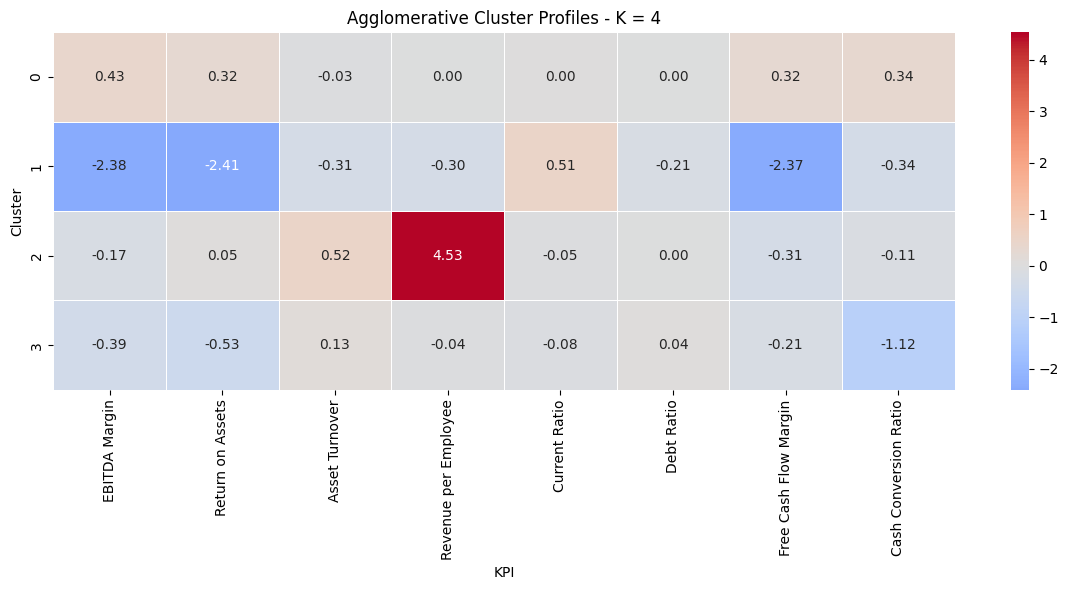

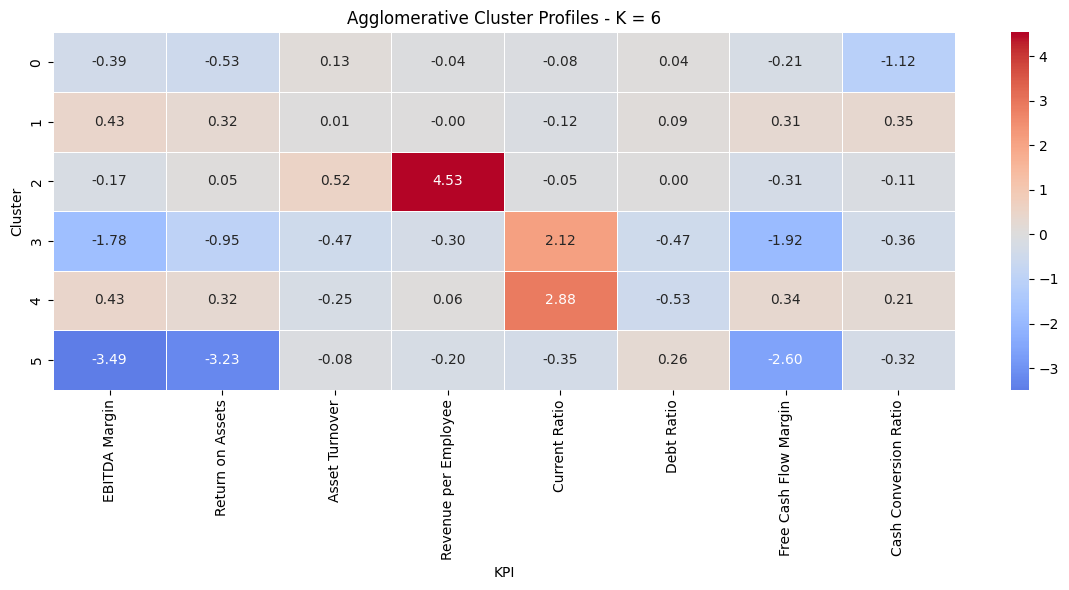

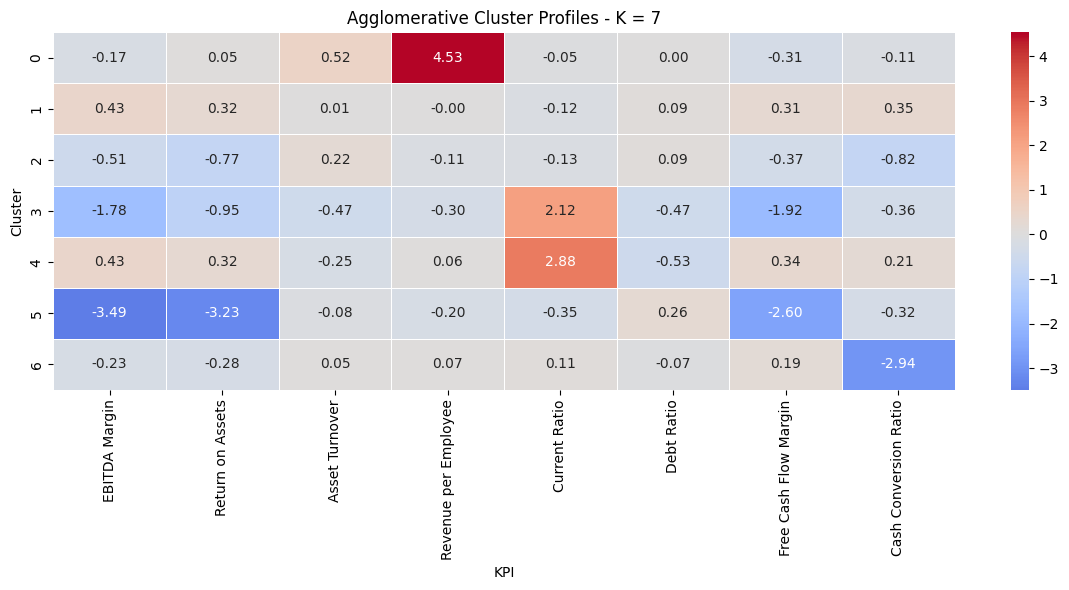

In [80]:
# ==================================================
# Agglomerative Candidate Cluster Profile Heatmaps
# ==================================================

for k, profile in agg_candidate_standardised_profiles.items():

    plt.figure(figsize=(12, 6))

    sns.heatmap(
        profile,
        annot=True,
        fmt=".2f",
        center=0,
        cmap="coolwarm",
        linewidths=0.5
    )

    plt.title(f"Agglomerative Cluster Profiles - K = {k}")
    plt.xlabel("KPI")
    plt.ylabel("Cluster")
    plt.tight_layout()
    plt.show()

For Agglomerative Clustering, I'll choose K=6

for this Technology / revenue ≥ $25M experiment

## 9.3 Gaussian Mixture Models

Gaussian Mixture Models are evaluated as a probabilistic alternative to K-Means and Agglomerative Clustering. Rather than assigning each company deterministically to a single cluster, GMM estimates the probability that each observation belongs to every cluster.

This soft-assignment approach can be very relevant to financial peer selection, as some companies may exhibit characteristics of multiple financial archetypes rather than fitting cleanly within a single peer group.

To ensure comparability with previous experiments, GMM is applied to the same four-component PCA representation and evaluated using the same internal validation metrics.

### 9.3.1 Evaluate Candidate Cluster Counts

In [81]:
# ==================================================
# Evaluate Gaussian Mixture Models
# ==================================================

from sklearn.mixture import GaussianMixture

gmm_results = []

for k in K_RANGE:

    model = GaussianMixture(
        n_components=k,
        covariance_type="full",
        random_state=RANDOM_STATE,
        n_init=10,
    )

    cluster_labels = model.fit_predict(X_cluster)

    gmm_results.append({
        "Model": "Gaussian Mixture",
        "K": k,
        "Silhouette Score": silhouette_score(
            X_cluster,
            cluster_labels
        ),
        "Davies-Bouldin Index": davies_bouldin_score(
            X_cluster,
            cluster_labels
        ),
        "Calinski-Harabasz Score": calinski_harabasz_score(
            X_cluster,
            cluster_labels
        ),
        "AIC": model.aic(X_cluster),
        "BIC": model.bic(X_cluster),
    })

gmm_results_df = pd.DataFrame(gmm_results)

gmm_results_df

,Model,K,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Score,AIC,BIC
0,Gaussian Mixture,2,0.254293,2.276902,100.093423,7119.191140,7246.116222
1,Gaussian Mixture,3,0.270513,1.606195,165.499963,6873.109042,7065.685028
2,Gaussian Mixture,4,0.263630,1.422348,171.173556,6599.356478,6857.583368
3,Gaussian Mixture,5,0.268021,1.592171,166.826275,6498.648605,6822.526399
4,Gaussian Mixture,6,0.230164,1.440857,150.029372,6327.309528,6716.838227
5,Gaussian Mixture,7,0.229873,1.398148,146.100193,6237.643134,6692.822737
6,Gaussian Mixture,8,0.203427,1.323506,141.791415,6013.577260,6534.407767
7,Gaussian Mixture,9,0.203903,1.317608,133.992217,5968.569705,6555.051116
8,Gaussian Mixture,10,0.209222,1.137737,146.313967,5921.817704,6573.950020


### 9.3.2 Identify Best K by Metric

In [82]:
# ==================================================
# Best K by Evaluation Metric
# ==================================================

best_gmm_silhouette_k = (
    gmm_results_df
    .loc[
        gmm_results_df["Silhouette Score"].idxmax(),
        "K"
    ]
)

best_gmm_davies_bouldin_k = (
    gmm_results_df
    .loc[
        gmm_results_df["Davies-Bouldin Index"].idxmin(),
        "K"
    ]
)

best_gmm_calinski_harabasz_k = (
    gmm_results_df
    .loc[
        gmm_results_df["Calinski-Harabasz Score"].idxmax(),
        "K"
    ]
)

best_gmm_aic_k = (
    gmm_results_df
    .loc[
        gmm_results_df["AIC"].idxmin(),
        "K"
    ]
)

best_gmm_bic_k = (
    gmm_results_df
    .loc[
        gmm_results_df["BIC"].idxmin(),
        "K"
    ]
)

print(f"Best K by Silhouette Score: {best_gmm_silhouette_k}")
print(f"Best K by Davies-Bouldin Index: {best_gmm_davies_bouldin_k}")
print(f"Best K by Calinski-Harabasz Score: {best_gmm_calinski_harabasz_k}")
print(f"Best K by AIC: {best_gmm_aic_k}")
print(f"Best K by BIC: {best_gmm_bic_k}")

Best K by Silhouette Score: 3
Best K by Davies-Bouldin Index: 10
Best K by Calinski-Harabasz Score: 4
Best K by AIC: 10
Best K by BIC: 8


### 9.3.3 Silhouette Score

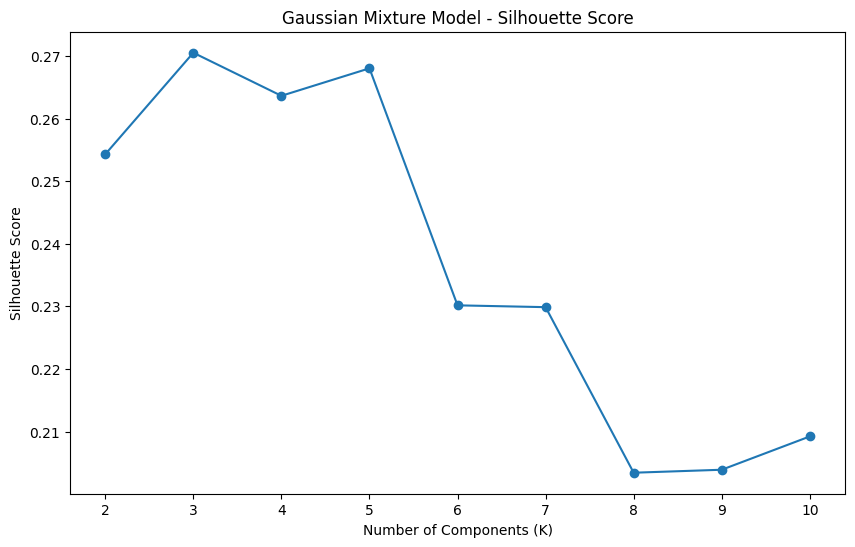

In [83]:
plt.figure(figsize=(10, 6))

plt.plot(
    gmm_results_df["K"],
    gmm_results_df["Silhouette Score"],
    marker="o",
)

plt.xlabel("Number of Components (K)")
plt.ylabel("Silhouette Score")
plt.title("Gaussian Mixture Model - Silhouette Score")
plt.xticks(list(K_RANGE))
plt.show()

### 9.3.4 Davies-Bouldin Index

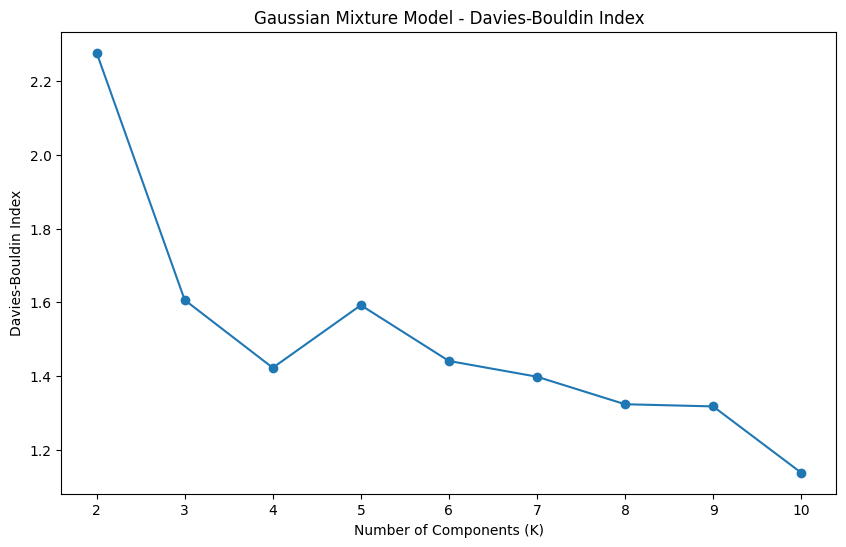

In [84]:
plt.figure(figsize=(10, 6))

plt.plot(
    gmm_results_df["K"],
    gmm_results_df["Davies-Bouldin Index"],
    marker="o",
)

plt.xlabel("Number of Components (K)")
plt.ylabel("Davies-Bouldin Index")
plt.title("Gaussian Mixture Model - Davies-Bouldin Index")
plt.xticks(list(K_RANGE))
plt.show()

### 9.3.5 Calinski-Harabasz Score

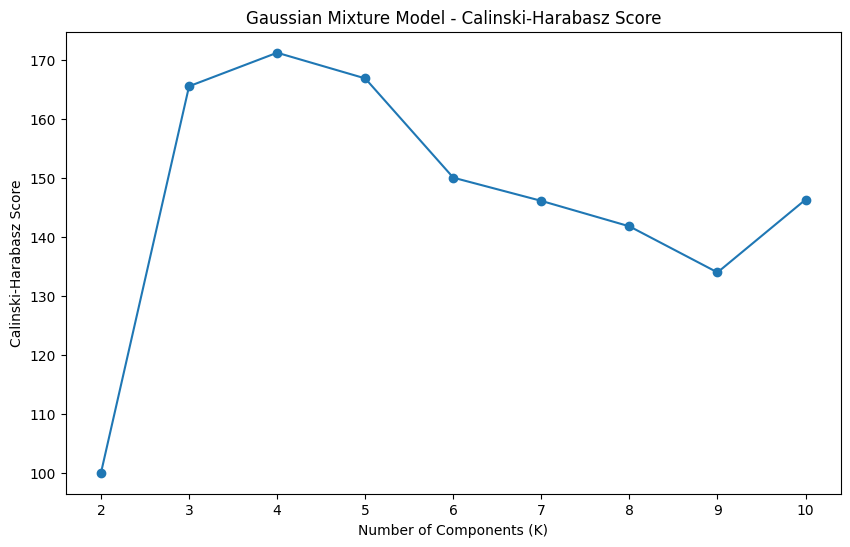

In [85]:
plt.figure(figsize=(10, 6))

plt.plot(
    gmm_results_df["K"],
    gmm_results_df["Calinski-Harabasz Score"],
    marker="o",
)

plt.xlabel("Number of Components (K)")
plt.ylabel("Calinski-Harabasz Score")
plt.title("Gaussian Mixture Model - Calinski-Harabasz Score")
plt.xticks(list(K_RANGE))
plt.show()

### 9.2.6 Plot AIC and BIC

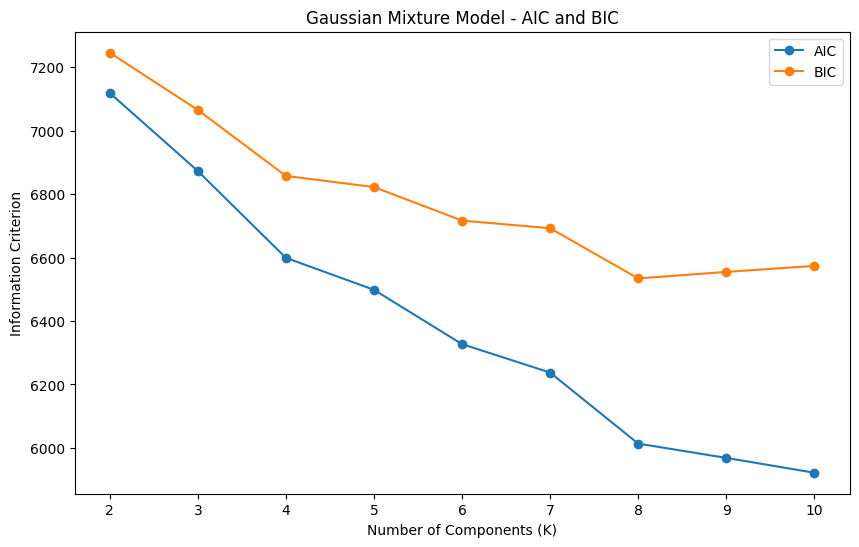

In [86]:
# ==================================================
# AIC and BIC
# ==================================================

plt.figure(figsize=(10, 6))

plt.plot(
    gmm_results_df["K"],
    gmm_results_df["AIC"],
    marker="o",
    label="AIC",
)

plt.plot(
    gmm_results_df["K"],
    gmm_results_df["BIC"],
    marker="o",
    label="BIC",
)

plt.xlabel("Number of Components (K)")
plt.ylabel("Information Criterion")
plt.title("Gaussian Mixture Model - AIC and BIC")
plt.xticks(list(K_RANGE))
plt.legend()
plt.show()

### 9.3.7 Compare Against Existing Algorithms

In [87]:
# ==================================================
# Compare Traditional Clustering Algorithms
# ==================================================

traditional_model_comparison_df = pd.concat([
    kmeans_results_df[
        [
            "Model",
            "K",
            "Silhouette Score",
            "Davies-Bouldin Index",
            "Calinski-Harabasz Score",
        ]
    ],
    agglomerative_results_df,
    gmm_results_df[
        [
            "Model",
            "K",
            "Silhouette Score",
            "Davies-Bouldin Index",
            "Calinski-Harabasz Score",
        ]
    ],
], ignore_index=True)

traditional_model_comparison_df

,Model,K,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Score
0,K-Means,2,0.319061,1.369437,249.046472
1,K-Means,3,0.348711,1.143806,240.160732
2,K-Means,4,0.349593,1.057253,277.647527
3,K-Means,5,0.366551,0.978495,273.430977
4,K-Means,6,0.362804,1.002467,260.779147
5,K-Means,7,0.370703,0.993112,257.927914
6,K-Means,8,0.316147,1.054260,254.259554
7,K-Means,9,0.320375,1.011666,252.947603
8,K-Means,10,0.322486,1.017627,245.270329
9,Agglomerative,2,0.295106,1.450031,208.256556


Update configuration table

In [88]:
best_configurations = pd.DataFrame([
    {
        "Model": "K-Means",
        "Best Silhouette K": best_silhouette_k,
        "Best DBI K": best_davies_bouldin_k,
        "Best CH K": best_calinski_harabasz_k,
    },
    {
        "Model": "Agglomerative",
        "Best Silhouette K": best_agg_silhouette_k,
        "Best DBI K": best_agg_davies_bouldin_k,
        "Best CH K": best_agg_calinski_harabasz_k,
    },
    {
        "Model": "Gaussian Mixture",
        "Best Silhouette K": best_gmm_silhouette_k,
        "Best DBI K": best_gmm_davies_bouldin_k,
        "Best CH K": best_gmm_calinski_harabasz_k,
    },
])

best_configurations

,Model,Best Silhouette K,Best DBI K,Best CH K
0,K-Means,7,5,4
1,Agglomerative,6,7,4
2,Gaussian Mixture,3,10,4


### 9.3.8 Candidate GMM Solutions

In [89]:
gmm_candidate_k_values = [3, 4, 5, 8]

In [90]:
# ==================================================
# Fit Candidate GMM Solutions
# ==================================================

gmm_candidate_cluster_results = {}

for k in gmm_candidate_k_values:

    model = GaussianMixture(
        n_components=k,
        covariance_type="full",
        random_state=RANDOM_STATE,
        n_init=10,
    )

    labels = model.fit_predict(X_cluster)
    probabilities = model.predict_proba(X_cluster)

    gmm_candidate_cluster_results[k] = {
        "model": model,
        "labels": labels,
        "probabilities": probabilities,
    }

### 9.3.9 Cluster Size Balance

In [91]:
# ==================================================
# Candidate GMM Cluster Sizes
# ==================================================

gmm_cluster_size_records = []

for k, result in gmm_candidate_cluster_results.items():

    cluster_sizes = (
        pd.Series(result["labels"])
        .value_counts()
        .sort_index()
    )

    print(f"\nK = {k}")
    print(cluster_sizes)

    for cluster, size in cluster_sizes.items():
        gmm_cluster_size_records.append({
            "K": k,
            "Cluster": cluster,
            "Company Count": size,
            "Cluster Share": size / len(X_cluster),
        })

gmm_cluster_size_summary_df = pd.DataFrame(
    gmm_cluster_size_records
)

gmm_cluster_size_summary_df


K = 3
0    151
1    342
2     95
Name: count, dtype: int64

K = 4
0    165
1    223
2     87
3    113
Name: count, dtype: int64

K = 5
0    217
1     94
2    106
3     54
4    117
Name: count, dtype: int64

K = 8
0     67
1    175
2     94
3     76
4     48
5     53
6     36
7     39
Name: count, dtype: int64


,K,Cluster,Company Count,Cluster Share
0,3,0,151,0.256803
1,3,1,342,0.581633
2,3,2,95,0.161565
3,4,0,165,0.280612
4,4,1,223,0.379252
5,4,2,87,0.147959
6,4,3,113,0.192177
7,5,0,217,0.369048
8,5,1,94,0.159864
9,5,2,106,0.180272


In [92]:
gmm_cluster_balance_summary = (
    gmm_cluster_size_summary_df
    .groupby("K")
    .agg(
        Smallest_Cluster=("Company Count", "min"),
        Largest_Cluster=("Company Count", "max"),
        Smallest_Share=("Cluster Share", "min"),
        Largest_Share=("Cluster Share", "max"),
    )
)

gmm_cluster_balance_summary

,Smallest_Cluster,Largest_Cluster,Smallest_Share,Largest_Share
K,,,,
3,95,342,0.161565,0.581633
4,87,223,0.147959,0.379252
5,54,217,0.091837,0.369048
8,36,175,0.061224,0.297619


### 9.3.10 Membership Confidence Analysis

In [93]:
# ==================================================
# Membership Confidence Analysis
# ==================================================

gmm_confidence_summaries = {}

for k, result in gmm_candidate_cluster_results.items():

    probabilities = result["probabilities"]

    max_probability = probabilities.max(axis=1)

    confidence_summary = pd.Series(
        max_probability
    ).describe(
        percentiles=[0.10, 0.25, 0.50, 0.75, 0.90]
    )

    gmm_confidence_summaries[k] = confidence_summary

    print(f"\nK = {k}")
    display(confidence_summary)


K = 3


count    588.000000
mean       0.940717
std        0.115247
min        0.464726
10%        0.777290
25%        0.957306
50%        0.992100
75%        0.999468
90%        1.000000
max        1.000000
dtype: float64


K = 4


count    588.000000
mean       0.943001
std        0.115683
min        0.425971
10%        0.776913
25%        0.964047
50%        0.994402
75%        0.999504
90%        1.000000
max        1.000000
dtype: float64


K = 5


count    588.000000
mean       0.941514
std        0.106900
min        0.491904
10%        0.794915
25%        0.949003
50%        0.988318
75%        0.996443
90%        0.998744
max        1.000000
dtype: float64


K = 8


count    588.000000
mean       0.942446
std        0.102209
min        0.473938
10%        0.804901
25%        0.950851
50%        0.984532
75%        0.997331
90%        0.999665
max        1.000000
dtype: float64

In [94]:
# ==================================================
# Ambiguous Membership Rates
# ==================================================

confidence_thresholds = [0.50, 0.60, 0.70, 0.80]

gmm_ambiguity_records = []

for k, result in gmm_candidate_cluster_results.items():

    max_probability = result["probabilities"].max(axis=1)

    for threshold in confidence_thresholds:

        ambiguous_share = (
            max_probability < threshold
        ).mean()

        gmm_ambiguity_records.append({
            "K": k,
            "Confidence Threshold": threshold,
            "Ambiguous Company Share": ambiguous_share,
        })

gmm_ambiguity_summary_df = pd.DataFrame(
    gmm_ambiguity_records
)

gmm_ambiguity_summary_df

,K,Confidence Threshold,Ambiguous Company Share
0,3,0.5,0.005102
1,3,0.6,0.037415
2,3,0.7,0.074830
3,3,0.8,0.119048
4,4,0.5,0.005102
5,4,0.6,0.037415
6,4,0.7,0.071429
7,4,0.8,0.117347
8,5,0.5,0.001701
9,5,0.6,0.032313


### 9.3.11 Candidate Cluster Profile Comparison

In [95]:
# ==================================================
# Build Candidate GMM Cluster Profiles
# ==================================================

gmm_candidate_cluster_profiles = {}

for k, result in gmm_candidate_cluster_results.items():

    profile_df = peer_universe_df.copy()
    profile_df["Cluster"] = result["labels"]

    cluster_profile = (
        profile_df
        .groupby("Cluster")[balanced_clustering_kpis]
        .median()
    )

    gmm_candidate_cluster_profiles[k] = cluster_profile

    print(f"\nK = {k}")
    display(cluster_profile)


K = 3


,EBITDA Margin,Return on Assets,Asset Turnover,Revenue per Employee,Current Ratio,Debt Ratio,Free Cash Flow Margin,Cash Conversion Ratio
Cluster,,,,,,,,
0,0.127005,0.052648,0.646025,1.031322e+06,2.618533,0.088948,0.102357,1.340110
1,0.125465,0.028105,0.625137,3.408975e+05,1.643102,0.213257,0.129990,1.317084
2,-0.316858,-0.232935,0.541344,3.006212e+05,1.659286,0.190599,-0.142968,0.253558



K = 4


,EBITDA Margin,Return on Assets,Asset Turnover,Revenue per Employee,Current Ratio,Debt Ratio,Free Cash Flow Margin,Cash Conversion Ratio
Cluster,,,,,,,,
0,0.104388,0.050915,0.665314,950200.776645,2.601925,0.086511,0.079503,1.321424
1,0.188336,0.049314,0.602476,326486.027588,1.579522,0.229723,0.144969,1.915132
2,-0.338407,-0.234467,0.536089,284768.928571,1.737633,0.186315,-0.176626,0.293488
3,0.026941,-0.033475,0.667930,363318.668281,1.722444,0.205120,0.074222,-2.461920



K = 5


,EBITDA Margin,Return on Assets,Asset Turnover,Revenue per Employee,Current Ratio,Debt Ratio,Free Cash Flow Margin,Cash Conversion Ratio
Cluster,,,,,,,,
0,0.185812,0.049113,0.602476,3.260784e+05,1.561907,0.232048,0.143419,1.923213
1,-0.315823,-0.224862,0.542060,2.980820e+05,1.759672,0.182537,-0.120632,0.251262
2,0.023756,-0.033475,0.684145,3.488583e+05,1.737326,0.208125,0.063390,-2.274179
3,-0.058247,-0.060280,0.541196,1.049046e+06,1.713260,0.109328,-0.108306,-0.078738
4,0.201282,0.096842,0.641145,8.929157e+05,2.850026,0.068071,0.185494,1.570103



K = 8


,EBITDA Margin,Return on Assets,Asset Turnover,Revenue per Employee,Current Ratio,Debt Ratio,Free Cash Flow Margin,Cash Conversion Ratio
Cluster,,,,,,,,
0,0.013420,-0.057752,0.706031,3.256881e+05,1.692134,0.272078,0.046530,-1.065644
1,0.201928,0.060499,0.606311,3.176441e+05,1.603931,0.202252,0.145421,1.649203
2,-0.315823,-0.224862,0.542060,3.006212e+05,1.722490,0.184642,-0.120632,0.251262
3,0.210003,0.108822,0.835028,1.145299e+06,2.006355,0.206454,0.188494,1.461843
4,0.102598,0.011660,0.590610,3.703208e+05,1.538326,0.250525,0.141922,10.069973
5,-0.060425,-0.067138,0.633060,1.070118e+06,1.681595,0.109328,-0.067323,-0.166495
6,0.039394,-0.013362,0.672651,3.953539e+05,1.924605,0.131081,0.125748,-8.564206
7,0.192153,0.066361,0.462641,4.469968e+05,6.482053,0.018073,0.161175,1.562210


In [96]:
# ==================================================
# Standardised GMM Cluster Profiles
# ==================================================

gmm_candidate_standardised_profiles = {}

for k, result in gmm_candidate_cluster_results.items():

    scaled_profile_df = balanced_model_features_df.copy()
    scaled_profile_df["Cluster"] = result["labels"]

    standardised_profile = (
        scaled_profile_df
        .groupby("Cluster")[balanced_clustering_kpis]
        .median()
    )

    gmm_candidate_standardised_profiles[k] = standardised_profile

    print(f"\nK = {k}")
    display(standardised_profile)


K = 3


,EBITDA Margin,Return on Assets,Asset Turnover,Revenue per Employee,Current Ratio,Debt Ratio,Free Cash Flow Margin,Cash Conversion Ratio
Cluster,,,,,,,,
0,0.147455,0.279240,0.066030,1.826814,0.506449,-0.281530,0.058127,0.100336
1,0.140667,0.079841,0.014431,-0.080658,-0.092669,0.078519,0.206148,0.089319
2,-1.804059,-2.020505,-0.134723,-0.188057,-0.082729,0.030546,-1.151017,-0.420855



K = 4


,EBITDA Margin,Return on Assets,Asset Turnover,Revenue per Employee,Current Ratio,Debt Ratio,Free Cash Flow Margin,Cash Conversion Ratio
Cluster,,,,,,,,
0,0.047796,0.265284,0.103021,1.589685,0.496248,-0.282604,-0.041287,0.088143
1,0.417695,0.252139,-0.017428,-0.115095,-0.131721,0.127143,0.280622,0.376886
2,-1.898629,-2.032847,-0.144800,-0.216425,-0.034607,0.016126,-1.318368,-0.401680
3,-0.293454,-0.406285,0.098172,-0.039401,-0.043937,0.077617,-0.071132,-1.724868



K = 5


,EBITDA Margin,Return on Assets,Asset Turnover,Revenue per Employee,Current Ratio,Debt Ratio,Free Cash Flow Margin,Cash Conversion Ratio
Cluster,,,,,,,,
0,0.406573,0.250216,-0.017428,-0.126207,-0.142540,0.135799,0.272919,0.377231
1,-1.794871,-1.955498,-0.133349,-0.195655,-0.021071,0.003408,-1.039959,-0.421957
2,-0.307488,-0.414293,0.139134,-0.047289,-0.034796,0.084477,-0.124993,-1.634712
3,-0.668817,-0.616307,-0.069135,1.831828,-0.049577,-0.201501,-0.978676,-0.574071
4,0.474737,0.635126,0.056670,1.446776,0.648634,-0.333686,0.478358,0.211295



K = 8


,EBITDA Margin,Return on Assets,Asset Turnover,Revenue per Employee,Current Ratio,Debt Ratio,Free Cash Flow Margin,Cash Conversion Ratio
Cluster,,,,,,,,
0,-0.353033,-0.597652,0.141319,-0.136607,-0.062553,0.273652,-0.208822,-1.054355
1,0.477583,0.340561,-0.008379,-0.160756,-0.116728,0.042049,0.282873,0.247283
2,-1.794871,-1.955498,-0.133349,-0.195655,-0.043908,0.010495,-1.039959,-0.421957
3,0.513167,0.731600,0.428491,2.169427,0.130444,0.059286,0.497032,0.158559
4,0.039911,-0.050831,-0.040243,-0.005254,-0.157023,0.168100,0.265475,1.858459
5,-0.678414,-0.685375,0.041166,1.836842,-0.069026,-0.232115,-0.774906,-0.585647
6,-0.238584,-0.252323,0.117092,0.042722,0.080232,-0.117905,0.185057,-2.943692
7,0.434515,0.389668,-0.285656,0.151907,2.879457,-0.544284,0.338547,0.207580


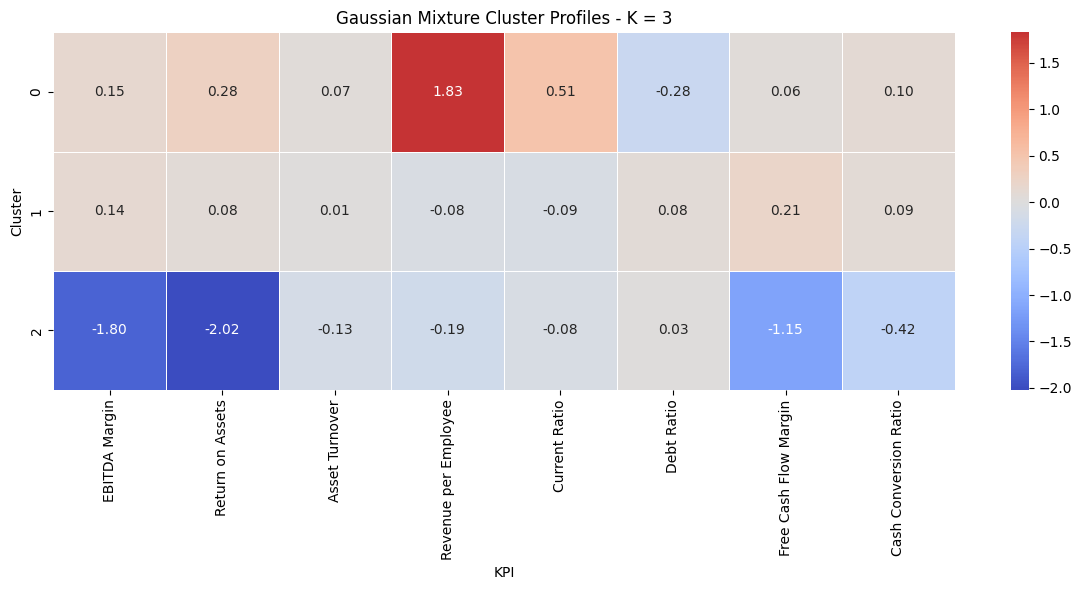

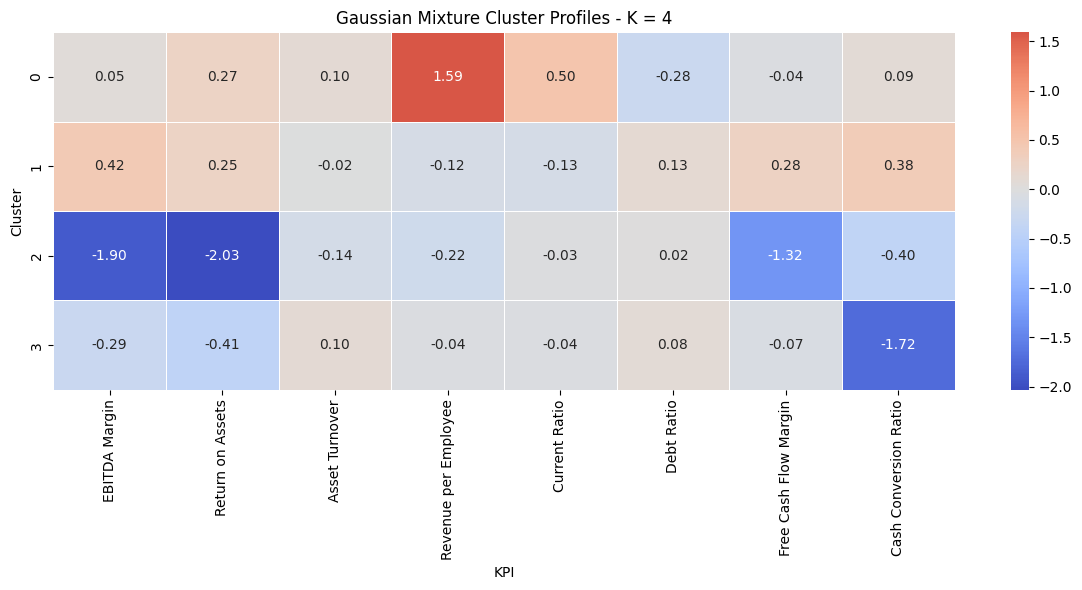

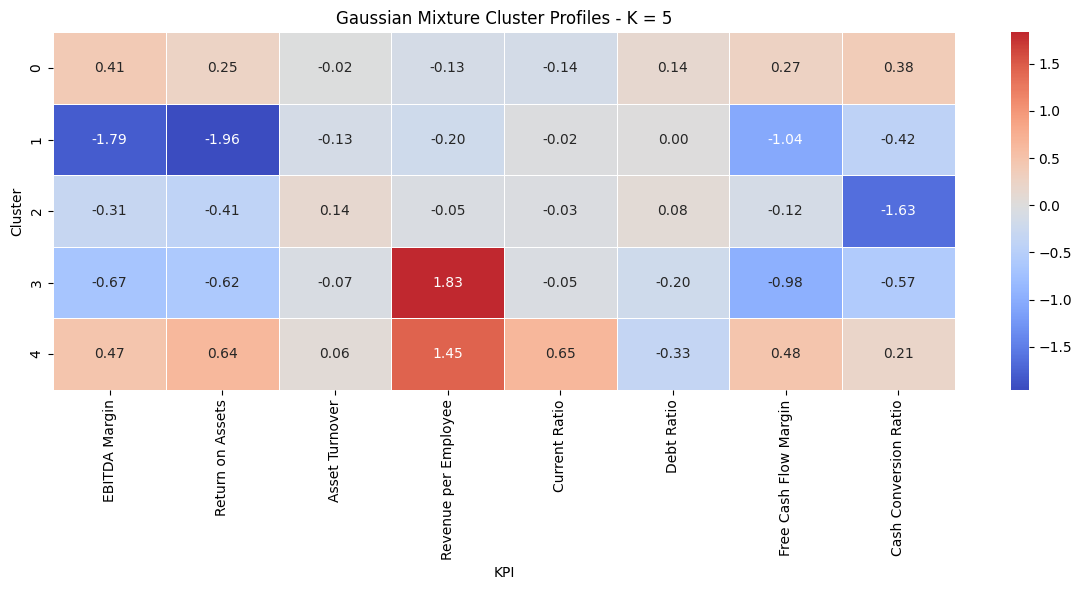

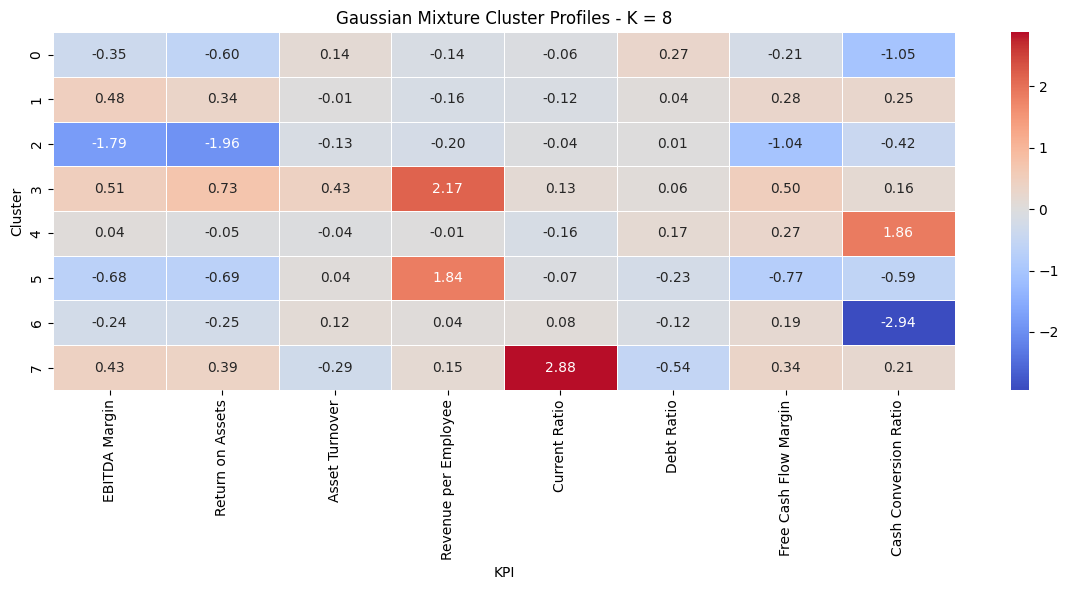

In [97]:
# ==================================================
# Candidate GMM Cluster Profile Heatmaps
# ==================================================

for k, profile in gmm_candidate_standardised_profiles.items():

    plt.figure(figsize=(12, 6))

    sns.heatmap(
        profile,
        annot=True,
        fmt=".2f",
        center=0,
        cmap="coolwarm",
        linewidths=0.5,
    )

    plt.title(f"Gaussian Mixture Cluster Profiles - K = {k}")
    plt.xlabel("KPI")
    plt.ylabel("Cluster")
    plt.tight_layout()
    plt.show()

Preferred GMM configuration: K=5,
because it gives the best balance of:

- interpretable archetypes
- healthy cluster sizes
- strong membership confidence
- manageable complexity
- direct comparability with K-Means K=5

## 9.4 Density-Based Clustering with HDBSCAN

HDBSCAN is evaluated as a density-based alternative to the centroid-based, hierarchical and probabilistic methods examined previously. Rather than requiring every company to be assigned to a predefined number of clusters, HDBSCAN identifies stable dense regions in the feature space and may classify isolated observations as noise.

This characteristic is particularly relevant to automated financial peer selection, as some companies may not have sufficiently similar peers within the selected comparison universe. As with previous experiments, HDBSCAN is applied to the same four-component PCA representation.

In [98]:
from sklearn.cluster import HDBSCAN

### 9.4.1 Evaluate candidate minimum cluster sizes

In [99]:
MIN_CLUSTER_SIZES = [10, 15, 20, 25]
MIN_SAMPLES_VALUES = [5, 10, 15]

In [101]:
# ==================================================
# HDBSCAN Parameter Sensitivity Analysis
# ==================================================

hdbscan_tuning_results = []
hdbscan_tuning_candidate_results = {}

for min_cluster_size in MIN_CLUSTER_SIZES:
    for min_samples in MIN_SAMPLES_VALUES:

        model = HDBSCAN(
            min_cluster_size=min_cluster_size,
            min_samples=min_samples,
        )

        labels = model.fit_predict(X_cluster)

        non_noise_mask = labels != -1

        n_clusters = len(set(labels) - {-1})
        noise_count = (labels == -1).sum()
        noise_share = noise_count / len(labels)

        result = {
            "Min Cluster Size": min_cluster_size,
            "Min Samples": min_samples,
            "Number of Clusters": n_clusters,
            "Noise Count": noise_count,
            "Noise Share": noise_share,
        }

        if n_clusters >= 2 and non_noise_mask.sum() > n_clusters:

            result.update({
                "Silhouette Score": silhouette_score(
                    X_cluster[non_noise_mask],
                    labels[non_noise_mask],
                ),
                "Davies-Bouldin Index": davies_bouldin_score(
                    X_cluster[non_noise_mask],
                    labels[non_noise_mask],
                ),
                "Calinski-Harabasz Score": calinski_harabasz_score(
                    X_cluster[non_noise_mask],
                    labels[non_noise_mask],
                ),
            })

        else:

            result.update({
                "Silhouette Score": np.nan,
                "Davies-Bouldin Index": np.nan,
                "Calinski-Harabasz Score": np.nan,
            })

        # Store evaluation metrics
        hdbscan_tuning_results.append(result)

        # Store model outputs using BOTH parameters as the key
        hdbscan_tuning_candidate_results[
            (min_cluster_size, min_samples)
        ] = {
            "model": model,
            "labels": labels,
        }


hdbscan_tuning_results_df = pd.DataFrame(
    hdbscan_tuning_results
)

hdbscan_tuning_results_df

,Min Cluster Size,Min Samples,Number of Clusters,Noise Count,Noise Share,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Score
0,10,5,5,236,0.401361,0.467794,0.685629,236.521217
1,10,10,3,306,0.520408,0.485200,0.699859,252.305885
2,10,15,3,349,0.593537,0.509209,0.652650,259.813215
3,15,5,4,247,0.420068,0.470286,0.708144,282.234128
4,15,10,3,306,0.520408,0.485200,0.699859,252.305885
5,15,15,3,349,0.593537,0.509209,0.652650,259.813215
6,20,5,3,262,0.445578,0.460132,0.794721,277.772476
7,20,10,3,306,0.520408,0.485200,0.699859,252.305885
8,20,15,3,349,0.593537,0.509209,0.652650,259.813215
9,25,5,3,262,0.445578,0.460132,0.794721,277.772476


### 9.4.2 Add cluster balance diagnostics

In [102]:
# ==================================================
# HDBSCAN Tuned Cluster Size Summary
# ==================================================

hdbscan_cluster_size_records = []

for (
    min_cluster_size,
    min_samples,
), result in hdbscan_tuning_candidate_results.items():

    labels = result["labels"]

    cluster_sizes = (
        pd.Series(labels[labels != -1])
        .value_counts()
        .sort_index()
    )

    for cluster, size in cluster_sizes.items():

        hdbscan_cluster_size_records.append({
            "Min Cluster Size": min_cluster_size,
            "Min Samples": min_samples,
            "Cluster": cluster,
            "Company Count": size,
            "Cluster Share": size / len(labels),
        })


hdbscan_cluster_size_summary_df = pd.DataFrame(
    hdbscan_cluster_size_records
)

hdbscan_cluster_size_summary_df

,Min Cluster Size,Min Samples,Cluster,Company Count,Cluster Share
0,10,5,0,15,0.025510
1,10,5,1,11,0.018707
2,10,5,2,34,0.057823
3,10,5,3,216,0.367347
4,10,5,4,76,0.129252
5,10,10,0,199,0.338435
6,10,10,1,58,0.098639
7,10,10,2,25,0.042517
8,10,15,0,28,0.047619
9,10,15,1,172,0.292517


In [103]:
# ==================================================
# HDBSCAN Cluster Balance Summary
# ==================================================

hdbscan_cluster_balance_summary = (
    hdbscan_cluster_size_summary_df
    .groupby([
        "Min Cluster Size",
        "Min Samples",
    ])
    .agg(
        Smallest_Cluster=("Company Count", "min"),
        Largest_Cluster=("Company Count", "max"),
        Smallest_Share=("Cluster Share", "min"),
        Largest_Share=("Cluster Share", "max"),
    )
)

hdbscan_cluster_balance_summary

Smallest_Cluster  Largest_Cluster  \
Min Cluster Size Min Samples                                      
10               5                          11              216   
                 10                         25              199   
                 15                         28              172   
15               5                          15              216   
                 10                         25              199   
                 15                         28              172   
20               5                          34              216   
                 10                         25              199   
                 15                         28              172   
25               5                          34              216   
                 10                         25              199   
                 15                         28              172   

                              Smallest_Share  Largest_Share  
Min Cluster Size Min Samples                                 
10               5                  0.018707       0.367347  
                 10                 0.042517       0.338435  
                 15                 0.047619       0.292517  
15               5                  0.025510       0.367347  
                 10                 0.042517       0.338435  
                 15                 0.047619       0.292517  
20               5                  0.057823       0.367347  
                 10                 0.042517       0.338435  
                 15                 0.047619       0.292517  
25               5                  0.057823       0.367347  
                 10                 0.042517       0.338435  
                 15                 0.047619       0.292517

### 9.4.3 Candidate Cluster Profile Comparison

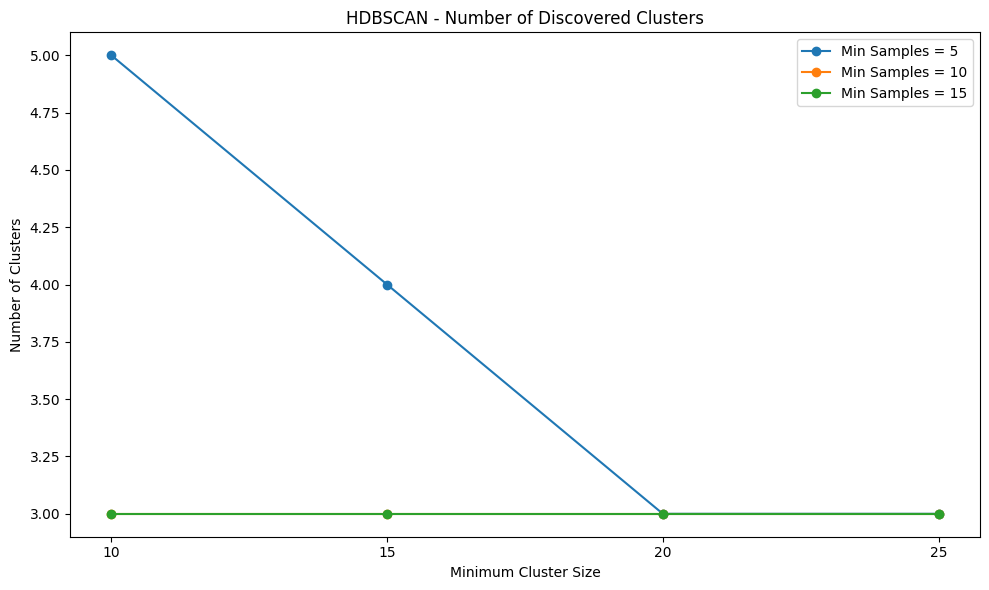

In [106]:
# ==================================================
# HDBSCAN - Number of Discovered Clusters
# ==================================================

plt.figure(figsize=(10, 6))

for min_samples in MIN_SAMPLES_VALUES:

    subset = hdbscan_tuning_results_df[
        hdbscan_tuning_results_df["Min Samples"] == min_samples
    ].sort_values("Min Cluster Size")

    plt.plot(
        subset["Min Cluster Size"],
        subset["Number of Clusters"],
        marker="o",
        label=f"Min Samples = {min_samples}",
    )

plt.xlabel("Minimum Cluster Size")
plt.ylabel("Number of Clusters")
plt.title("HDBSCAN - Number of Discovered Clusters")
plt.xticks(MIN_CLUSTER_SIZES)
plt.legend()
plt.tight_layout()
plt.show()

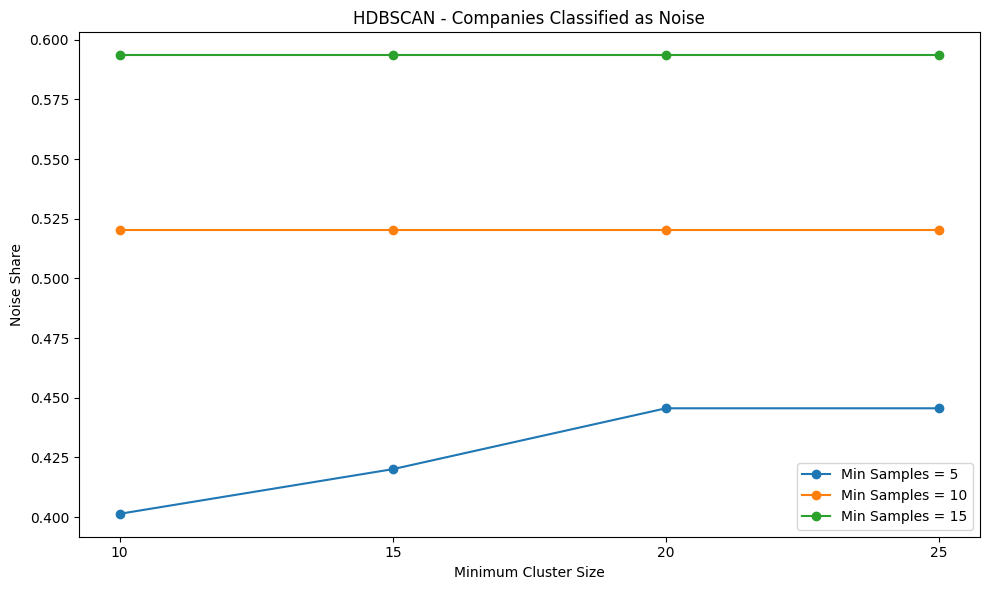

In [107]:
# ==================================================
# HDBSCAN - Companies Classified as Noise
# ==================================================

plt.figure(figsize=(10, 6))

for min_samples in MIN_SAMPLES_VALUES:

    subset = hdbscan_tuning_results_df[
        hdbscan_tuning_results_df["Min Samples"] == min_samples
    ].sort_values("Min Cluster Size")

    plt.plot(
        subset["Min Cluster Size"],
        subset["Noise Share"],
        marker="o",
        label=f"Min Samples = {min_samples}",
    )

plt.xlabel("Minimum Cluster Size")
plt.ylabel("Noise Share")
plt.title("HDBSCAN - Companies Classified as Noise")
plt.xticks(MIN_CLUSTER_SIZES)
plt.legend()
plt.tight_layout()
plt.show()

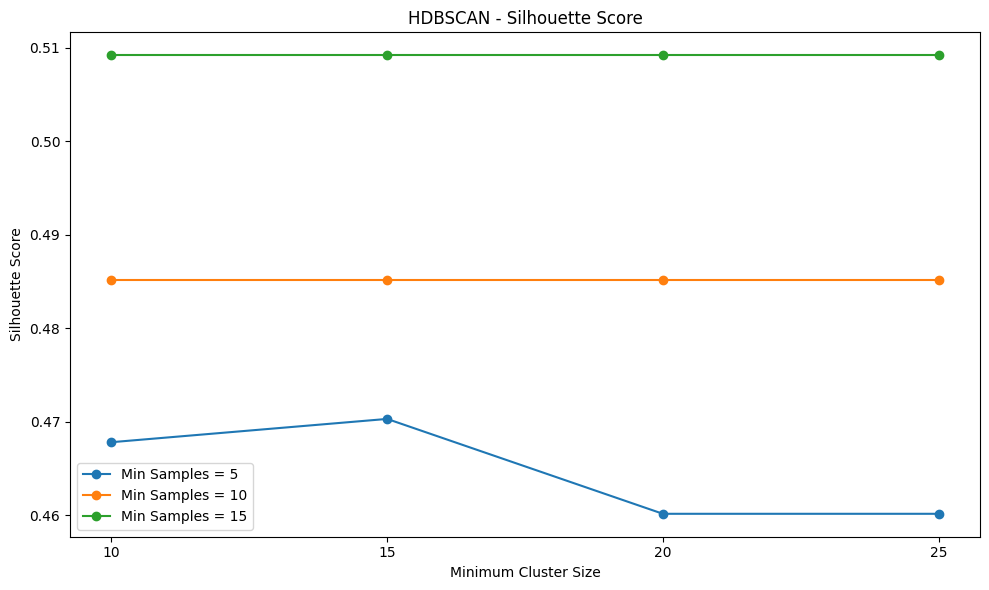

In [109]:
# ==================================================
# HDBSCAN - Silhouette Score
# ==================================================

plt.figure(figsize=(10, 6))

for min_samples in MIN_SAMPLES_VALUES:

    subset = hdbscan_tuning_results_df[
        hdbscan_tuning_results_df["Min Samples"] == min_samples
    ].sort_values("Min Cluster Size")

    plt.plot(
        subset["Min Cluster Size"],
        subset["Silhouette Score"],
        marker="o",
        label=f"Min Samples = {min_samples}",
    )

plt.xlabel("Minimum Cluster Size")
plt.ylabel("Silhouette Score")
plt.title("HDBSCAN - Silhouette Score")
plt.xticks(MIN_CLUSTER_SIZES)
plt.legend()
plt.tight_layout()
plt.show()

For Technology, Revenue >= $25M, min cluster sizes [20, 30, 40, 50, 75, 100]:

HDBSCAN produced the strongest separation among the companies it assigned to clusters, but achieved this by excluding approximately 63% of the peer universe as noise.

In [110]:
# Next step is to profile the three different configurations